# 08 — Model Training

**Author:** Florian Klaver

**Prerequisites:**
- Notebook 07 produced `data/training_samples_fusion.csv` (S2 + GRD events)
- Notebook 07 produced `data/training_samples_fusion_coh.csv` (+ InSAR coherence)

---

## Experiment design

Feature sets are derived from the permutation importance analysis (Section 2 below).

| Group | Dataset | Configs |
|---|---|---|
| **A** | `SAMPLES_FUSION_CSV` — all events with S1 GRD coverage | S2-only, GRD-only, S2+GRD |
| **B** | `SAMPLES_FUSION_COH_CSV` — coherence-eligible subset | Coh-only, CohJumps-only, S2+CohJumps, S2+Coh, Full-fusion | 

<br>

| Config | Feature set | n | Group |
|---|---|---|---|
| **S2-only** | ndii_diff, gndvi_diff, ndii_after, swir_after, evi_diff, green_after, swir_diff | 7 | A |
| **GRD-only** | vv_after, vh_after, cr_diff, vh_diff | 4 | A |
| **S2+GRD** | S2-only + GRD-only | 11 | A |
| **Coh-only** | coh_vv, coh_vh, coh_vv_jump, coh_vh_jump | 4 | B |
| **CohJumps-only** | coh_vv_jump, coh_vh_jump | 2 | B |
| **S2+CohJumps** | S2-only + CohJumps-only | 9 | B |
| **S2+Coh** | S2-only + Coh-only | 11 | B |
| **Full-fusion** | S2-only + GRD-only + Coh-only | 15 | B |

Each group has its own `GroupShuffleSplit(random_state=42, group=match_id)`.
Within-group comparisons are valid; cross-group F1 scores reflect different event populations.

---
## 1. Setup & Load Data

In [34]:
import sys
import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

sys.path.insert(0, os.path.abspath('..'))
from src.evaluation import (
    FEATURE_NAMES, prepare_data, evaluate_model,
    train_tuned_svm, train_tuned_rf, train_tuned_lgbm,
    find_optimal_threshold,
)
from src.config import *

os.makedirs(MODELS_DIR, exist_ok=True)

# Path to image fodler for report
IMG_DIR = DOCS_DIR

# Feature constants used by the feature selection analysis (Section 2 below)
SAR_FEATURES = ['vv_after', 'vh_after', 'cr_after', 'vv_diff', 'vh_diff', 'cr_diff']
COH_FEATURES = ['coh_vv', 'coh_vh', 'coh_vv_jump', 'coh_vh_jump']

# Group A: all events with S1 GRD coverage (S2 + GRD feature columns available)
fusion_df = pd.read_csv(SAMPLES_FUSION_CSV)
print(f'Group A (fusion): {len(fusion_df)} rows, {fusion_df["match_id"].nunique()} events')
print(f'Class balance:    {fusion_df["label"].value_counts().to_dict()}')

# Group B: events with valid InSAR coherence (coherence features non-NaN)
coh_raw = pd.read_csv(SAMPLES_FUSION_COH_CSV)
coh_df  = coh_raw.dropna(subset=COH_FEATURES).copy()
print(f'\nGroup B (coh):    {len(coh_df)} rows, {coh_df["match_id"].nunique()} events')
print(f'Class balance:    {coh_df["label"].value_counts().to_dict()}')

Group A (fusion): 33368 rows, 63 events
Class balance:    {1: 18077, 0: 15291}

Group B (coh):    17609 rows, 33 events
Class balance:    {1: 8936, 0: 8673}


---
## 2. Train/Test Splits

Two separate group-aware train/test splits — one per dataset group:

- **Group A:** `training_samples_fusion.csv` — all 63 events with S1 GRD coverage.
  Used for S2-only, GRD-only, and S2+GRD configs.
- **Group B:** `training_samples_fusion_coh.csv` — coherence-eligible subset (~33 events).
  Used for Coh-only, CohJumps-only, S2+CohJumps, S2+Coh, and Full-fusion configs.

Both splits use `GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42, group=match_id)`.
A comprehensive feature superset is passed to `prepare_data` for splitting purposes; training cells
then slice the per-config feature subset from the returned DataFrames.
Cross-group F1 comparisons are not meaningful — different event populations and test sets.

In [30]:
# Feature supersets for each group — splits performed here; training cells slice per-config.
# S2_BEST and GRD_BEST are derived by the feature selection analysis below;
# their exact values are hardcoded here so the split can run before that section executes.
_GROUP_A_FEATS = [
    'ndii_diff', 'gndvi_diff', 'ndii_after', 'swir_after', 'evi_diff',   # S2_BEST (7)
    'green_after', 'swir_diff',
    'vv_after', 'vh_after', 'cr_diff', 'vh_diff',                         # GRD_BEST (4)
]
_GROUP_B_FEATS = _GROUP_A_FEATS + ['coh_vv', 'coh_vh', 'coh_vv_jump', 'coh_vh_jump']  # + COH_ALL (4)

X_train_A, y_train_A, groups_train_A, X_test_A, y_test_A = prepare_data(
    fusion_df, _GROUP_A_FEATS, random_state=42
)
print(f'Group A — Train: {len(X_train_A)} samples ({groups_train_A.nunique()} events), '
      f'Test: {len(X_test_A)} samples ({fusion_df.loc[X_test_A.index, "match_id"].nunique()} events)')

X_train_B, y_train_B, groups_train_B, X_test_B, y_test_B = prepare_data(
    coh_df, _GROUP_B_FEATS, random_state=42
)
print(f'Group B — Train: {len(X_train_B)} samples ({groups_train_B.nunique()} events), '
      f'Test: {len(X_test_B)} samples ({coh_df.loc[X_test_B.index, "match_id"].nunique()} events)')

Training: 24945 samples (50 matches)
Testing:  8423 samples (13 matches)
Group A — Train: 24945 samples (50 events), Test: 8423 samples (13 events)
Training: 15088 samples (26 matches)
Testing:  2521 samples (7 matches)
Group B — Train: 15088 samples (26 events), Test: 2521 samples (7 events)


---
## Feature Selection and Configuration Design

Feature selection is performed exclusively on the **training split** to prevent test-set leakage. The coherence-eligible subset is used because it is the only split containing all 30 features (20 S2 optical + 6 GRD backscatter + 4 InSAR coherence). The feature-selection train/test split uses the same `GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42, group=match_id)` as every other split in this notebook.

Three complementary methods are applied and then combined into a single decision table:

1. **Pearson correlation analysis** — identifies linearly redundant feature pairs within and across modalities. Pairs with |r| > 0.85 are candidates for pruning; of a correlated pair the one with lower permutation importance is marked REDUNDANT.

2. **Mean Decrease Impurity (MDI)** — ranks features by their average contribution to decision node purity inside a preliminary `RandomForestClassifier(n_estimators=200, random_state=42)` trained on the full 30-feature training set. Fast and model-integrated, but can over-rate highly correlated or high-cardinality features.

3. **Permutation importance** — each feature is shuffled 20 times on a held-out `GroupKFold` validation fold (not the test set) and the mean F1 decrease is recorded. Model-agnostic and directly tied to generalisation performance. Features with mean ≤ 0 are DROP candidates.

The resulting lean feature sets (`S2_BEST`, `GRD_BEST`) are used to define all experiment configurations at the end of this section, and should be compared against the hardcoded `S2_LEAN_FEATURES` / `SAR_FEATURES` constants defined in the Setup cell above.

──────────────────────────────────────────────────────────────────────
STEP 2 — Pearson Correlation (training set only)
──────────────────────────────────────────────────────────────────────
Feature-selection training set: 15088 samples, 26 events (coherence subset)


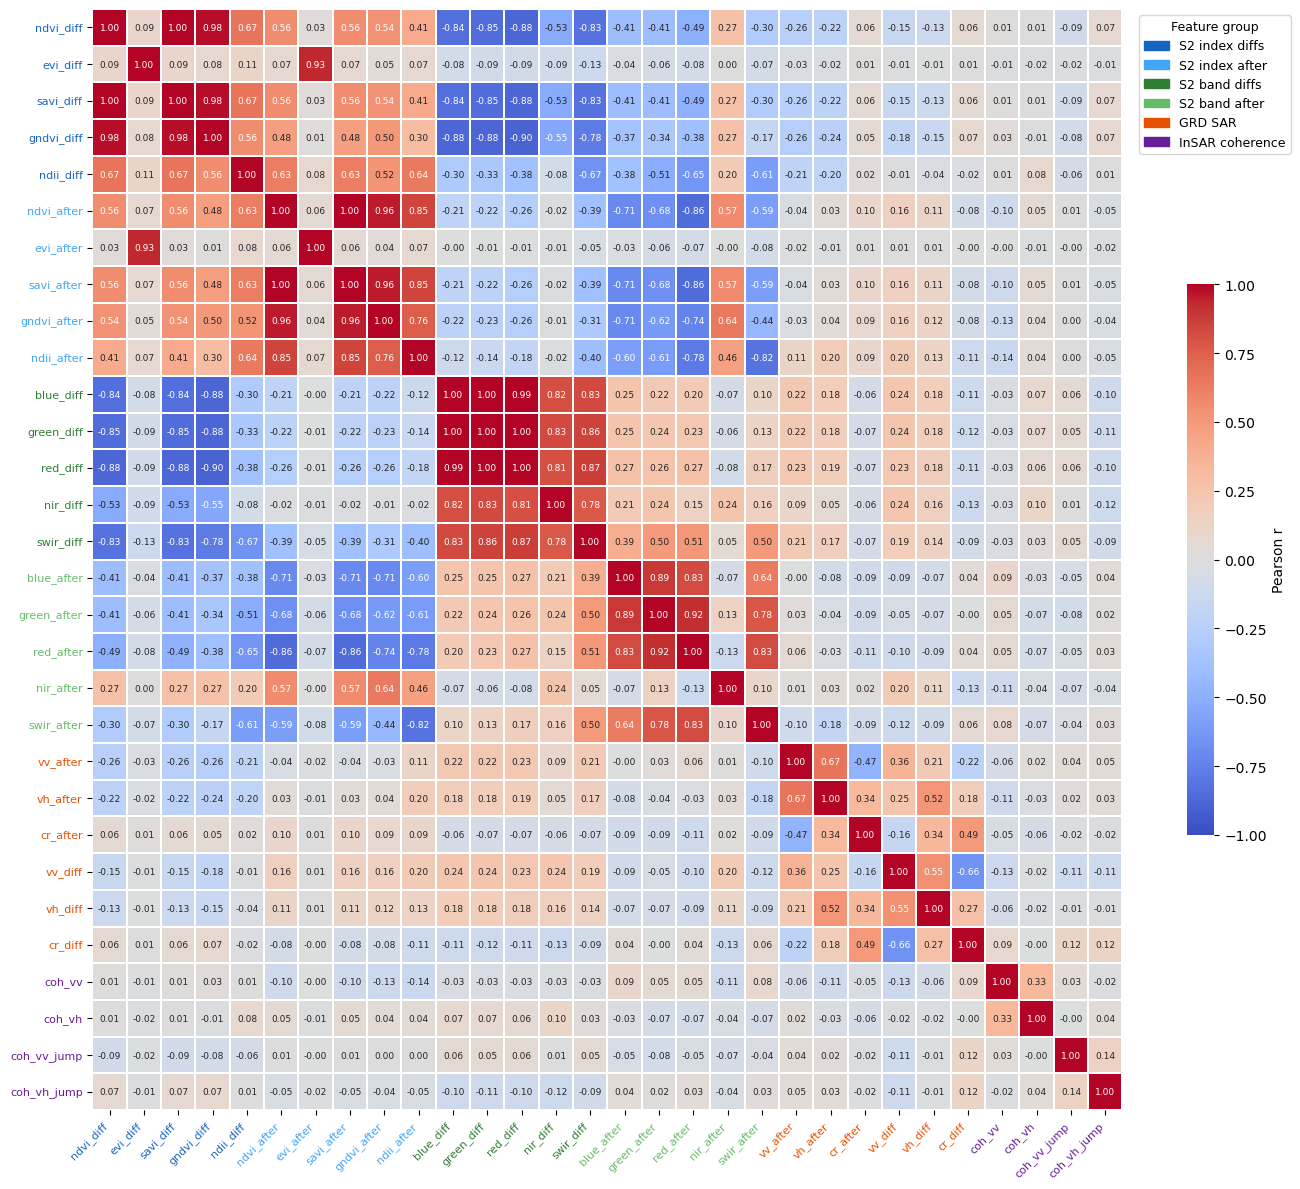

Saved → C:\Workspace\ZHAW\6_Semester\satellite-mowing-detection\docs\images\pearson_correlation.png

Highly correlated feature pairs (|r| > 0.85, sorted by |r| desc):
  savi_after             ↔  ndvi_after              r = +1.000  [S2 index after × S2 index after]
  savi_diff              ↔  ndvi_diff               r = +1.000  [S2 index diffs × S2 index diffs]
  green_diff             ↔  blue_diff               r = +0.998  [S2 band diffs × S2 band diffs]
  red_diff               ↔  green_diff              r = +0.997  [S2 band diffs × S2 band diffs]
  red_diff               ↔  blue_diff               r = +0.995  [S2 band diffs × S2 band diffs]
  gndvi_diff             ↔  savi_diff               r = +0.979  [S2 index diffs × S2 index diffs]
  gndvi_diff             ↔  ndvi_diff               r = +0.979  [S2 index diffs × S2 index diffs]
  gndvi_after            ↔  savi_after              r = +0.957  [S2 index after × S2 index after]
  gndvi_after            ↔  ndvi_after              r =

In [39]:
import seaborn as sns
import matplotlib.patches as mpatches

# ── STEP 2 — Pearson Correlation Matrix ──────────────────────────────────────
# Training split only; never touches the test set.

print('─' * 70)
print('STEP 2 — Pearson Correlation (training set only)')
print('─' * 70)

# ── Feature group definitions (order sets heatmap layout) ───────────────────
FS_S2_INDEX_DIFF  = ['ndvi_diff',  'evi_diff',  'savi_diff',  'gndvi_diff',  'ndii_diff']
FS_S2_INDEX_AFTER = ['ndvi_after', 'evi_after', 'savi_after', 'gndvi_after', 'ndii_after']
FS_S2_BAND_DIFF   = ['blue_diff',  'green_diff', 'red_diff',  'nir_diff',    'swir_diff']
FS_S2_BAND_AFTER  = ['blue_after', 'green_after','red_after', 'nir_after',   'swir_after']
FS_ALL_S2  = FS_S2_INDEX_DIFF + FS_S2_INDEX_AFTER + FS_S2_BAND_DIFF + FS_S2_BAND_AFTER
FS_ALL_30  = FS_ALL_S2 + SAR_FEATURES + COH_FEATURES

GROUP_DEFS = [
    ('S2 index diffs',  FS_S2_INDEX_DIFF,  '#1565C0'),
    ('S2 index after',  FS_S2_INDEX_AFTER, '#42A5F5'),
    ('S2 band diffs',   FS_S2_BAND_DIFF,   '#2E7D32'),
    ('S2 band after',   FS_S2_BAND_AFTER,  '#66BB6A'),
    ('GRD SAR',         SAR_FEATURES,      '#E65100'),
    ('InSAR coherence', COH_FEATURES,      '#6A1B9A'),
]
_feat_color = {f: c for _, feats, c in GROUP_DEFS for f in feats}
_feat_group = {f: n for n, feats, _ in GROUP_DEFS for f in feats}

# Consistent bar-chart colors (blue S2 / orange GRD / purple Coh)
FS_COLOR_S2  = '#2196F3'
FS_COLOR_GRD = '#FF6D00'
FS_COLOR_COH = '#7B1FA2'

def _fs_bar_color(feat):
    if feat in COH_FEATURES: return FS_COLOR_COH
    if feat in SAR_FEATURES:  return FS_COLOR_GRD
    return FS_COLOR_S2

FS_LEGEND = [
    mpatches.Patch(color=FS_COLOR_S2,  label='S2 optical'),
    mpatches.Patch(color=FS_COLOR_GRD, label='GRD SAR'),
    mpatches.Patch(color=FS_COLOR_COH, label='InSAR coherence'),
]

# ── Feature-selection training split (same GSS params as every other split) ─
from sklearn.model_selection import GroupShuffleSplit as _GSS
_fs_base = coh_df[FS_ALL_30 + ['match_id', 'label']].dropna(subset=FS_ALL_30)
_gss_fs  = _GSS(n_splits=1, test_size=0.2, random_state=42)
_tr_idx, _ = next(_gss_fs.split(_fs_base[FS_ALL_30], _fs_base['label'], _fs_base['match_id']))
fs_train_df     = _fs_base.iloc[_tr_idx].copy()
fs_groups_train = fs_train_df['match_id']
print(f'Feature-selection training set: {len(fs_train_df)} samples, '
      f'{fs_groups_train.nunique()} events (coherence subset)')

# Output directory for all feature-selection plots
FS_DIR = RESULTS_DIR / 'feature_selection'
os.makedirs(FS_DIR, exist_ok=True)

# ── Pearson correlation on training features ─────────────────────────────────
corr_matrix = fs_train_df[FS_ALL_30].corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    corr_matrix.loc[FS_ALL_30, FS_ALL_30],
    annot=True, fmt='.2f', cmap='coolwarm',
    center=0, vmin=-1, vmax=1,
    annot_kws={'size': 6.5}, linewidths=0.2, linecolor='white',
    cbar_kws={'shrink': 0.5, 'label': 'Pearson r'},
    ax=ax,
)
#ax.set_title('Pearson Correlation — 30 features (coherence training set only)', fontsize=13)

# Colour tick labels by feature group
for tick in ax.get_yticklabels():
    tick.set_color(_feat_color.get(tick.get_text(), 'black'))
    tick.set_fontsize(8)
for tick in ax.get_xticklabels():
    tick.set_color(_feat_color.get(tick.get_text(), 'black'))
    tick.set_fontsize(8)
plt.xticks(rotation=45, ha='right')

_group_patches = [mpatches.Patch(color=c, label=n) for n, _, c in GROUP_DEFS]
ax.legend(handles=_group_patches, bbox_to_anchor=(1.01, 1), loc='upper left',
          fontsize=9, title='Feature group', title_fontsize=9)
plt.tight_layout()
fig.savefig(IMG_DIR / 'pearson_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {IMG_DIR / "pearson_correlation.png"}')

# ── High-correlation pairs ───────────────────────────────────────────────────
print('\nHighly correlated feature pairs (|r| > 0.85, sorted by |r| desc):')
_high = []
for _i, _f1 in enumerate(FS_ALL_30):
    for _j, _f2 in enumerate(FS_ALL_30):
        if _j >= _i:
            continue
        _r = corr_matrix.loc[_f1, _f2]
        if abs(_r) > 0.85:
            _high.append((abs(_r), _r, _f1, _f2))
_high.sort(reverse=True)

if _high:
    for _abs_r, _r, _f1, _f2 in _high:
        print(f'  {_f1:<22} ↔  {_f2:<22}  r = {_r:+.3f}'
              f'  [{_feat_group[_f1]} × {_feat_group[_f2]}]')
else:
    print('  None — no feature pairs exceed |r| = 0.85')

# Per-group redundancy summary
print()
for _gname, _gfeats, _ in GROUP_DEFS:
    _within = sum(1 for _, _, a, b in _high
                  if _feat_group.get(a) == _gname and _feat_group.get(b) == _gname)
    _cross  = sum(1 for _, _, a, b in _high
                  if (_feat_group.get(a) == _gname) != (_feat_group.get(b) == _gname))
    _parts = []
    if _within: _parts.append(f'{_within} within-group redundant pair(s)')
    if _cross:  _parts.append(f'{_cross} cross-group pair(s)')
    _status = ', '.join(_parts) if _parts else 'no pairs above threshold'
    print(f'  {_gname:<22}: {_status}')

──────────────────────────────────────────────────────────────────────
STEP 3 — Preliminary RF (n_estimators=200) for MDI  [not saved to models/]
──────────────────────────────────────────────────────────────────────
  Fold 1/5 — F1 = 0.8394
  Fold 2/5 — F1 = 0.9244
  Fold 3/5 — F1 = 0.8247
  Fold 4/5 — F1 = 0.9384
  Fold 5/5 — F1 = 0.8649

GroupKFold CV F1: 0.8784 ± 0.0454
Preliminary RF trained on 15088 samples (MDI extraction only).

MDI ranking (all 30 features):
   1. evi_diff                MDI = 0.13343  [S2 index diffs]
   2. ndii_diff               MDI = 0.11371  [S2 index diffs]
   3. ndvi_diff               MDI = 0.08505  [S2 index diffs]
   4. evi_after               MDI = 0.08105  [S2 index after]
   5. savi_diff               MDI = 0.07750  [S2 index diffs]
   6. ndii_after              MDI = 0.05338  [S2 index after]
   7. swir_after              MDI = 0.04458  [S2 band after]
   8. gndvi_after             MDI = 0.04181  [S2 index after]
   9. gndvi_diff              MDI

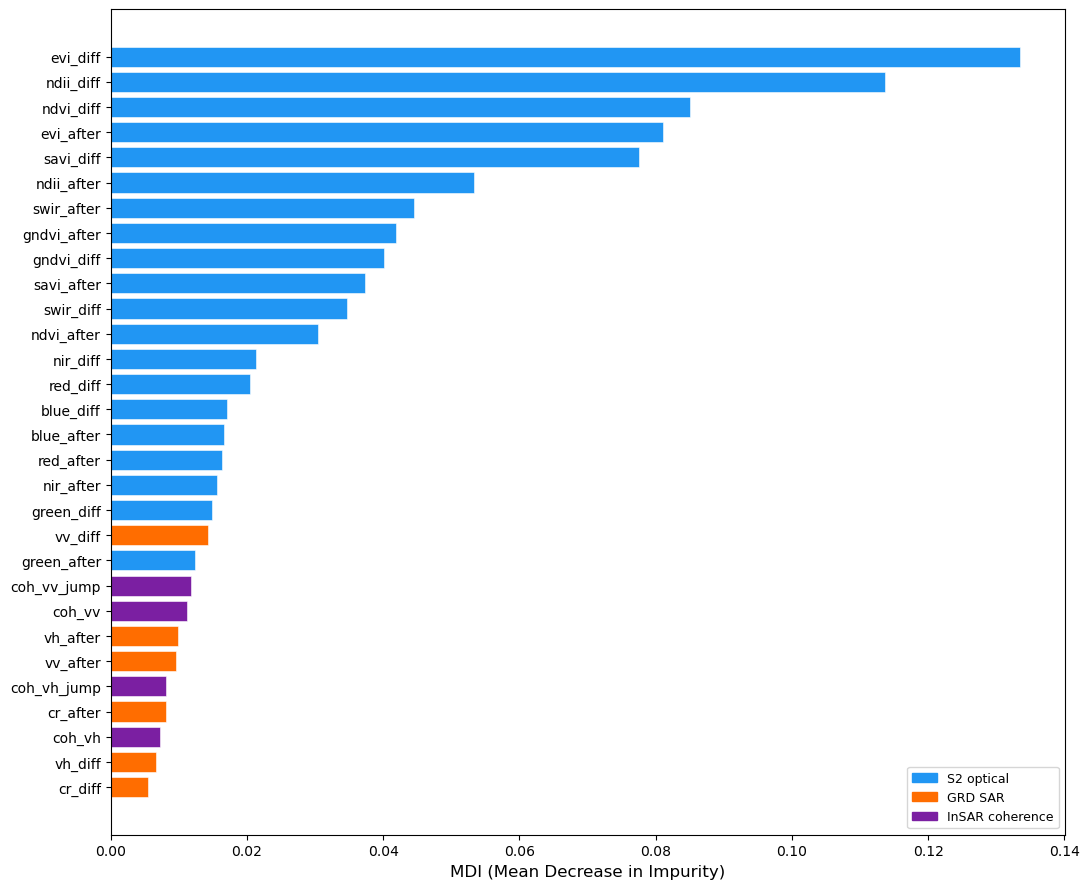

Saved → C:\Workspace\ZHAW\6_Semester\satellite-mowing-detection\docs\images\mdi_importance.png


In [41]:
# ── STEP 3 — Preliminary RF for MDI ─────────────────────────────────────────
# Trained on all 30 features using the feature-selection training split.
# FOR FEATURE SELECTION ONLY — this model is NOT saved to models/

print('─' * 70)
print('STEP 3 — Preliminary RF (n_estimators=200) for MDI  [not saved to models/]')
print('─' * 70)

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import f1_score as _f1

X_fs = fs_train_df[FS_ALL_30]
y_fs = fs_train_df['label']

# 5-fold GroupKFold CV for a stable performance estimate
_gkf_fs = GroupKFold(n_splits=5)
_cv_f1s = []
for _fold_i, (_tr, _va) in enumerate(_gkf_fs.split(X_fs, y_fs, fs_groups_train)):
    _tmp = RandomForestClassifier(n_estimators=200, max_depth=None,
                                   random_state=42, n_jobs=-1)
    _tmp.fit(X_fs.iloc[_tr], y_fs.iloc[_tr])
    _cv_f1s.append(_f1(y_fs.iloc[_va], _tmp.predict(X_fs.iloc[_va])))
    print(f'  Fold {_fold_i + 1}/5 — F1 = {_cv_f1s[-1]:.4f}')

print(f'\nGroupKFold CV F1: {np.mean(_cv_f1s):.4f} ± {np.std(_cv_f1s):.4f}')

# Final RF on all feature-selection training data — MDI extracted from this
_rf_full = RandomForestClassifier(n_estimators=200, max_depth=None,
                                   random_state=42, n_jobs=-1)
_rf_full.fit(X_fs, y_fs)
print(f'Preliminary RF trained on {len(X_fs)} samples (MDI extraction only).')

mdi_series = pd.Series(_rf_full.feature_importances_, index=FS_ALL_30).sort_values(ascending=False)

print('\nMDI ranking (all 30 features):')
for _rnk, (_feat, _val) in enumerate(mdi_series.items(), 1):
    print(f'  {_rnk:>2}. {_feat:<22}  MDI = {_val:.5f}  [{_feat_group[_feat]}]')

# Horizontal bar chart, colored by modality
_mp = mdi_series.sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(11, 9))
ax.barh(_mp.index, _mp.values,
        color=[_fs_bar_color(f) for f in _mp.index],
        edgecolor='white', linewidth=0.4)
ax.set_xlabel('MDI (Mean Decrease in Impurity)', fontsize=12)
#ax.set_title('Feature Importance (MDI) — Preliminary RF, all 30 features\n'
#             '[FOR FEATURE SELECTION ONLY — not saved to models/]', fontsize=11)
ax.legend(handles=FS_LEGEND, loc='lower right', fontsize=9)
plt.tight_layout()
fig.savefig(IMG_DIR / 'mdi_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {IMG_DIR / "mdi_importance.png"}')

──────────────────────────────────────────────────────────────────────
STEP 4 — Permutation Importance  [held-out fold, NOT the test set]
──────────────────────────────────────────────────────────────────────
Held-out fold — train: 12072 samples, val: 3016 samples
Fold RF trained. Held-out F1: 0.8649
Computing permutation importance (n_repeats=20, scoring=f1)...

Permutation Importance — all 30 features:
    feature      mean      std
  ndii_diff  0.071210 0.003103
 gndvi_diff  0.027981 0.002642
 ndii_after  0.020291 0.002393
 swir_after  0.014523 0.002926
 ndvi_after  0.013579 0.001067
 savi_after  0.009708 0.001265
coh_vv_jump  0.009584 0.001914
     coh_vv  0.008122 0.001735
   vv_after  0.006647 0.001588
gndvi_after  0.005793 0.000937
   evi_diff  0.005593 0.001771
   vh_after  0.004127 0.001365
green_after  0.002651 0.001123
    cr_diff  0.001965 0.000920
  evi_after  0.001459 0.002514
coh_vh_jump  0.001057 0.001250
    vh_diff  0.000897 0.001738
     coh_vh  0.000387 0.001209
  s

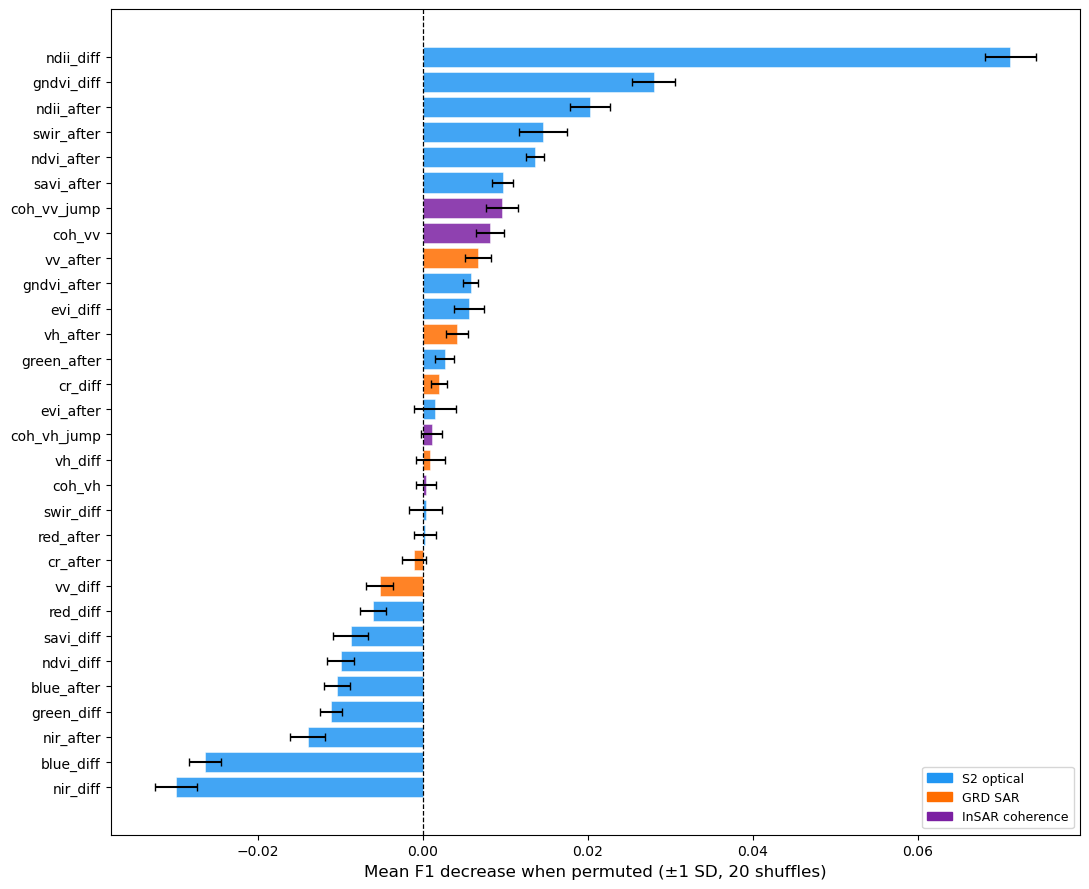

Saved → C:\Workspace\ZHAW\6_Semester\satellite-mowing-detection\docs\images\perm_importance.png


In [42]:
# ── STEP 4 — Permutation Importance (held-out GroupKFold fold) ───────────────
# A fold-specific RF is trained on 4/5 of the feature-selection training data.
# Permutation importance is evaluated on the held-out 5th fold — the RF has
# never seen those samples.  This is NOT the main test set.

print('─' * 70)
print('STEP 4 — Permutation Importance  [held-out fold, NOT the test set]')
print('─' * 70)

from sklearn.model_selection import GroupKFold
from sklearn.inspection import permutation_importance as _compute_perm_imp
from sklearn.metrics import f1_score as _f1_score

# Take the last fold from 5-fold GroupKFold as the held-out evaluation set
_gkf_perm = GroupKFold(n_splits=5)
_folds = list(_gkf_perm.split(X_fs, y_fs, fs_groups_train))
_perm_tr_idx, _perm_va_idx = _folds[-1]

X_perm_tr = X_fs.iloc[_perm_tr_idx]
y_perm_tr = y_fs.iloc[_perm_tr_idx]
X_perm_va = X_fs.iloc[_perm_va_idx]
y_perm_va = y_fs.iloc[_perm_va_idx]
print(f'Held-out fold — train: {len(X_perm_tr)} samples, '
      f'val: {len(X_perm_va)} samples')

# Train a fold-specific RF (FOR FEATURE SELECTION ONLY — never sees val data)
from sklearn.ensemble import RandomForestClassifier
_rf_perm = RandomForestClassifier(n_estimators=200, max_depth=None,
                                   random_state=42, n_jobs=-1)
_rf_perm.fit(X_perm_tr, y_perm_tr)
print(f'Fold RF trained. Held-out F1: '
      f'{_f1_score(y_perm_va, _rf_perm.predict(X_perm_va)):.4f}')

print('Computing permutation importance (n_repeats=20, scoring=f1)...')
_perm_result = _compute_perm_imp(
    _rf_perm, X_perm_va, y_perm_va,
    n_repeats=20, scoring='f1', random_state=42, n_jobs=-1,
)

perm_df = pd.DataFrame({
    'feature': FS_ALL_30,
    'mean':    _perm_result.importances_mean,
    'std':     _perm_result.importances_std,
}).sort_values('mean', ascending=False).reset_index(drop=True)

print('\nPermutation Importance — all 30 features:')
print(perm_df.to_string(index=False))

_zero_feats = perm_df[perm_df['mean'] <= 0.0]['feature'].tolist()
print(f'\nDROP candidates — mean ≤ 0 ({len(_zero_feats)} features):')
if _zero_feats:
    for _f in _zero_feats:
        _r = perm_df[perm_df['feature'] == _f].iloc[0]
        print(f'  {_f:<22}  mean={_r["mean"]:+.5f}  std={_r["std"]:.5f}'
              f'  [{_feat_group[_f]}]')
else:
    print('  None — all features have positive permutation importance')

# Bar chart with error bars
_pp = perm_df.sort_values('mean', ascending=True)
fig, ax = plt.subplots(figsize=(11, 9))
ax.barh(_pp['feature'], _pp['mean'], xerr=_pp['std'],
        color=[_fs_bar_color(f) for f in _pp['feature']],
        alpha=0.85, capsize=3, edgecolor='white', linewidth=0.4)
ax.axvline(0, color='black', lw=0.9, linestyle='--', label='zero (neutral)')
ax.set_xlabel('Mean F1 decrease when permuted (±1 SD, 20 shuffles)', fontsize=12)
#ax.set_title('Permutation Importance — Preliminary RF, all 30 features\n'
#             '(held-out GroupKFold fold — FOR FEATURE SELECTION ONLY)', fontsize=11)
ax.legend(handles=FS_LEGEND, loc='lower right', fontsize=9)
plt.tight_layout()
fig.savefig(IMG_DIR / 'perm_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {IMG_DIR / "perm_importance.png"}')

In [16]:
# ── STEP 5 — Feature Selection Summary and Decision Table ────────────────────
# Combines evidence from Pearson correlation, MDI, and permutation importance.
# Decision rules:
#   DROP      — permutation importance mean ≤ 0
#   REDUNDANT — |r| > 0.85 with a feature that has higher permutation importance
#   KEEP      — otherwise

print('─' * 70)
print('STEP 5 — Feature Selection Summary and Decisions')
print('─' * 70)

_perm_idx   = perm_df.set_index('feature')
_mdi_ranks  = mdi_series.rank(ascending=False).astype(int)
_perm_ranks = _perm_idx['mean'].rank(ascending=False).astype(int)

DROP_THRESHOLD = 0.0
CORR_THRESHOLD = 0.85

_rows = []
for feat in FS_ALL_30:
    max_r   = float(corr_matrix.loc[feat, [f for f in FS_ALL_30 if f != feat]].abs().max())
    mdi_r   = int(_mdi_ranks[feat])
    p_mean  = float(_perm_idx.loc[feat, 'mean'])
    p_rank  = int(_perm_ranks[feat])

    if p_mean <= DROP_THRESHOLD:
        rec = 'DROP'
    else:
        _partners = corr_matrix.loc[feat, [f for f in FS_ALL_30 if f != feat]]
        _partners = _partners[_partners.abs() > CORR_THRESHOLD].index.tolist()
        rec = 'REDUNDANT' if any(
            float(_perm_idx.loc[p, 'mean']) > p_mean for p in _partners
        ) else 'KEEP'

    _rows.append({
        'feature': feat, 'source_group': _feat_group[feat],
        'pearson_max_corr': round(max_r, 3),
        'MDI_rank': mdi_r, 'perm_rank': p_rank,
        'perm_mean': round(p_mean, 5), 'recommendation': rec,
    })

sel_df = pd.DataFrame(_rows).sort_values('perm_rank').reset_index(drop=True)

print('\nFeature selection summary (sorted by permutation importance rank):')
print(sel_df.to_string(index=False))

print('\nFinal feature sets by source group:')
for _gname, _, _ in GROUP_DEFS:
    _keep   = sel_df[(sel_df['source_group'] == _gname) & (sel_df['recommendation'] == 'KEEP')]['feature'].tolist()
    _remove = sel_df[(sel_df['source_group'] == _gname) & (sel_df['recommendation'] != 'KEEP')][
        ['feature', 'recommendation']].values.tolist()
    print(f'  {_gname:<22}: KEEP {_keep}')
    if _remove:
        for _f, _r in _remove:
            print(f'  {"":>22}  {_r:<10} {_f}')

_n_drop = (sel_df['recommendation'] == 'DROP').sum()
_n_red  = (sel_df['recommendation'] == 'REDUNDANT').sum()
_n_keep = (sel_df['recommendation'] == 'KEEP').sum()
print(f'\nTotal: {_n_keep} kept · {_n_drop} dropped (perm ≤ 0) · {_n_red} redundant (|r|>0.85, lower perm importance)')
print(f'Features removed: {_n_drop + _n_red} of {len(FS_ALL_30)}')

# Expose final feature sets for the CONFIGS cell
S2_BEST = sel_df[
    (sel_df['source_group'].isin(['S2 index diffs', 'S2 index after',
                                   'S2 band diffs',  'S2 band after'])) &
    (sel_df['recommendation'] == 'KEEP')
]['feature'].tolist()

GRD_BEST = sel_df[
    (sel_df['source_group'] == 'GRD SAR') &
    (sel_df['recommendation'] == 'KEEP')
]['feature'].tolist()

print(f'\nS2_BEST  ({len(S2_BEST)}): {S2_BEST}')
print(f'GRD_BEST ({len(GRD_BEST)}): {GRD_BEST}')

──────────────────────────────────────────────────────────────────────
STEP 5 — Feature Selection Summary and Decisions
──────────────────────────────────────────────────────────────────────

Feature selection summary (sorted by permutation importance rank):
    feature    source_group  pearson_max_corr  MDI_rank  perm_rank  perm_mean recommendation
  ndii_diff  S2 index diffs             0.666         2          1    0.07121           KEEP
 gndvi_diff  S2 index diffs             0.979         9          2    0.02798           KEEP
 ndii_after  S2 index after             0.851         6          3    0.02029           KEEP
 swir_after   S2 band after             0.826         7          4    0.01452           KEEP
 ndvi_after  S2 index after             1.000        12          5    0.01358      REDUNDANT
 savi_after  S2 index after             1.000        10          6    0.00971      REDUNDANT
coh_vv_jump InSAR coherence             0.135        22          7    0.00958           KE

In [17]:
# ── STEP 6 — Training Configurations ────────────────────────────────────────
# S2_BEST and GRD_BEST are defined by the feature selection summary above.
# COH_ALL / COH_JUMPS are fixed coherence feature subsets.

print('─' * 70)
print('STEP 6 — Training Configurations')
print('─' * 70)

COH_ALL   = COH_FEATURES                                # all 4 coherence features
COH_JUMPS = ['coh_vv_jump', 'coh_vh_jump']              # jump-only subset for ablation

CONFIGS = {
    'S2-only':       {'features': S2_BEST,                     'group': 'A'},
    'GRD-only':      {'features': GRD_BEST,                    'group': 'A'},
    'Coh-only':      {'features': COH_ALL,                     'group': 'B'},
    'CohJumps-only': {'features': COH_JUMPS,                   'group': 'B'},
    'S2+CohJumps':   {'features': S2_BEST + COH_JUMPS,         'group': 'B'},
    'S2+Coh':        {'features': S2_BEST + COH_ALL,           'group': 'B'},
    'S2+GRD':        {'features': S2_BEST + GRD_BEST,          'group': 'A'},
    'Full-fusion':   {'features': S2_BEST + GRD_BEST + COH_ALL,'group': 'B'},
}

print(f'\n{"Config":<18} {"Group":<8} {"n":<5} Features')
print('─' * 80)
for name, cfg in CONFIGS.items():
    print(f'  {name:<16} {cfg["group"]:<8} {len(cfg["features"]):<5} {cfg["features"]}')

print('\nGroup A — full fusion dataset (training_samples_fusion.csv).')
print('Group B — coherence-eligible subset (training_samples_fusion_coh.csv).')
print(f'\nS2_BEST  ({len(S2_BEST)}): {S2_BEST}')
print(f'GRD_BEST ({len(GRD_BEST)}): {GRD_BEST}')

──────────────────────────────────────────────────────────────────────
STEP 6 — Training Configurations
──────────────────────────────────────────────────────────────────────

Config             Group    n     Features
────────────────────────────────────────────────────────────────────────────────
  S2-only          A        7     ['ndii_diff', 'gndvi_diff', 'ndii_after', 'swir_after', 'evi_diff', 'green_after', 'swir_diff']
  GRD-only         A        4     ['vv_after', 'vh_after', 'cr_diff', 'vh_diff']
  Coh-only         B        4     ['coh_vv', 'coh_vh', 'coh_vv_jump', 'coh_vh_jump']
  CohJumps-only    B        2     ['coh_vv_jump', 'coh_vh_jump']
  S2+CohJumps      B        9     ['ndii_diff', 'gndvi_diff', 'ndii_after', 'swir_after', 'evi_diff', 'green_after', 'swir_diff', 'coh_vv_jump', 'coh_vh_jump']
  S2+Coh           B        11    ['ndii_diff', 'gndvi_diff', 'ndii_after', 'swir_after', 'evi_diff', 'green_after', 'swir_diff', 'coh_vv', 'coh_vh', 'coh_vv_jump', 'coh_vh_jump']

---
> *`S2_BEST` and `GRD_BEST` above were derived exclusively from the training split.
> The following sections train and evaluate every configuration defined in `CONFIGS`.
> Comparisons are only valid **within** groups A (full 63-event set) and B (coherence subset, 32 events);
> cross-group F1 scores reflect different evaluation populations and cannot be directly compared.*

---
## 3. Group A Training — S2-only, GRD-only, S2+GRD

All three configs use the Group A split (`fusion_df` — all 63 events with S1 GRD coverage).
Feature lists are sliced from `CONFIGS` defined by the permutation importance analysis above.
Results accumulate in `results_A`.

=== S2-only  (7 features, Group A) ===
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'rf__max_depth': 10, 'rf__n_estimators': 100}

--- S2-only RF ---
Accuracy: 91.77%
               precision    recall  f1-score   support

Not Mowed (0)       0.86      0.98      0.91      3702
    Mowed (1)       0.98      0.87      0.92      4721

     accuracy                           0.92      8423
    macro avg       0.92      0.92      0.92      8423
 weighted avg       0.93      0.92      0.92      8423



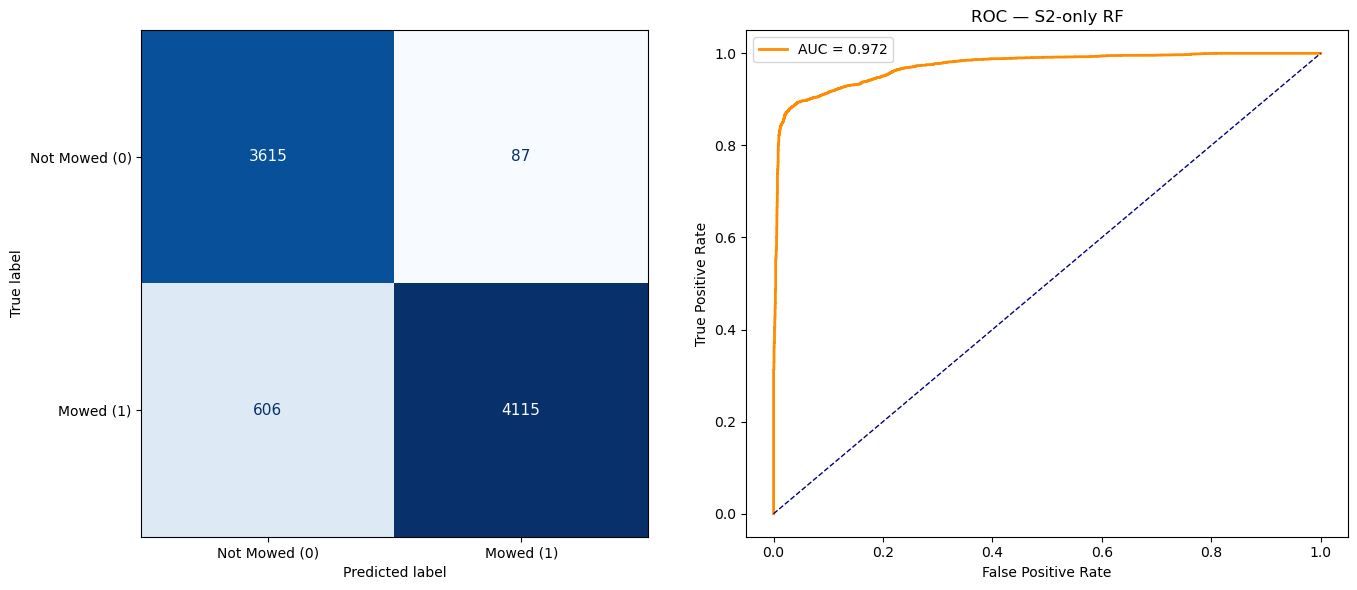

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'svm__C': 0.1, 'svm__gamma': 'scale'}

--- S2-only SVM ---
Accuracy: 92.10%
               precision    recall  f1-score   support

Not Mowed (0)       0.86      0.98      0.92      3702
    Mowed (1)       0.98      0.88      0.93      4721

     accuracy                           0.92      8423
    macro avg       0.92      0.93      0.92      8423
 weighted avg       0.93      0.92      0.92      8423



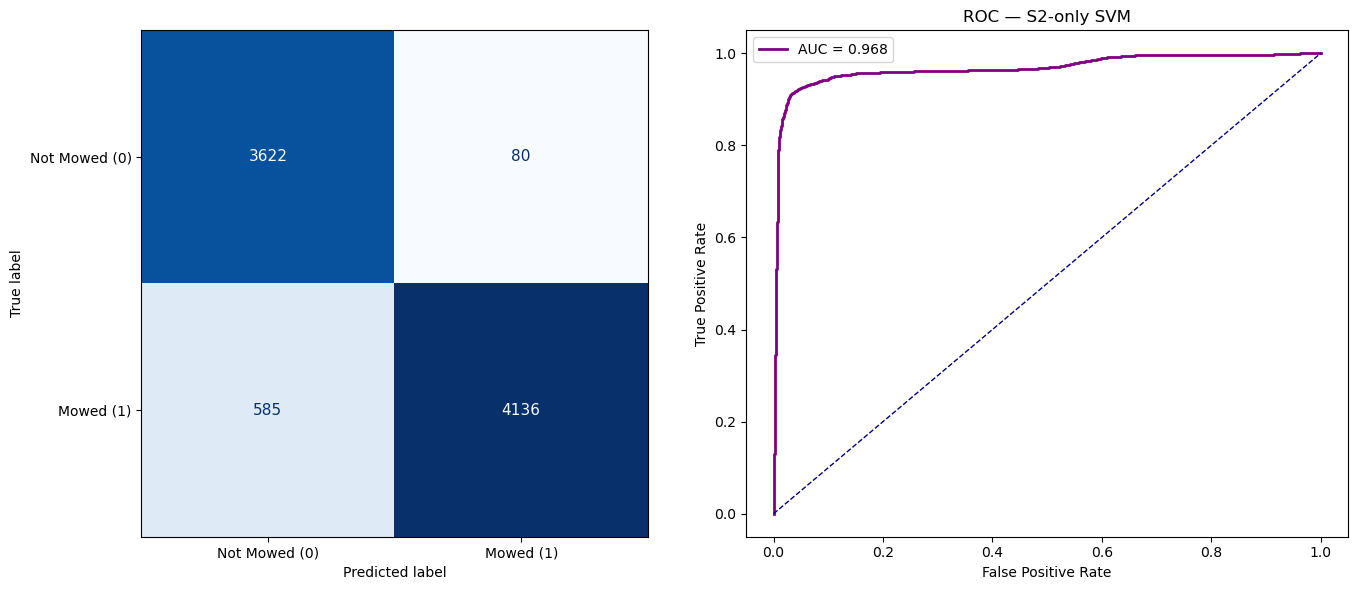

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best params: {'lgbm__learning_rate': 0.05, 'lgbm__num_leaves': 31}

--- S2-only LGBM ---
Accuracy: 91.04%
               precision    recall  f1-score   support

Not Mowed (0)       0.85      0.96      0.90      3702
    Mowed (1)       0.97      0.87      0.92      4721

     accuracy                           0.91      8423
    macro avg       0.91      0.92      0.91      8423
 weighted avg       0.92      0.91      0.91      8423



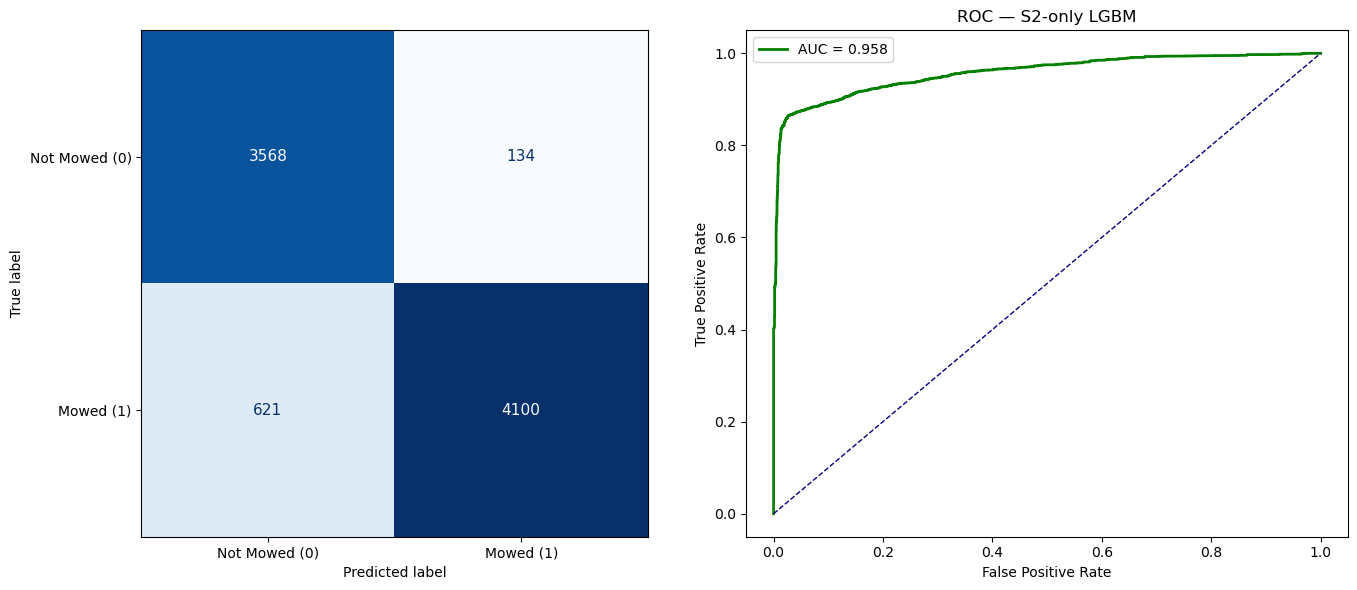

In [18]:
results_A = []

_feats = CONFIGS['S2-only']['features']
print(f'=== S2-only  ({len(_feats)} features, Group A) ===')
model_s2only_rf = train_tuned_rf(
    X_train_A[_feats], y_train_A, groups_train_A,
    X_test_A[_feats], y_test_A,
    results_list=results_A, model_alias='S2-only RF'
)
model_s2only_svm = train_tuned_svm(
    X_train_A[_feats], y_train_A, groups_train_A,
    X_test_A[_feats], y_test_A,
    results_list=results_A, model_alias='S2-only SVM'
)
model_s2only_lgbm = train_tuned_lgbm(
    X_train_A[_feats], y_train_A, groups_train_A,
    X_test_A[_feats], y_test_A,
    results_list=results_A, model_alias='S2-only LGBM'
)

=== GRD-only  (4 features, Group A) ===
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'rf__max_depth': 10, 'rf__n_estimators': 200}

--- GRD-only RF ---
Accuracy: 54.51%
               precision    recall  f1-score   support

Not Mowed (0)       0.48      0.40      0.43      3702
    Mowed (1)       0.58      0.66      0.62      4721

     accuracy                           0.55      8423
    macro avg       0.53      0.53      0.53      8423
 weighted avg       0.54      0.55      0.54      8423



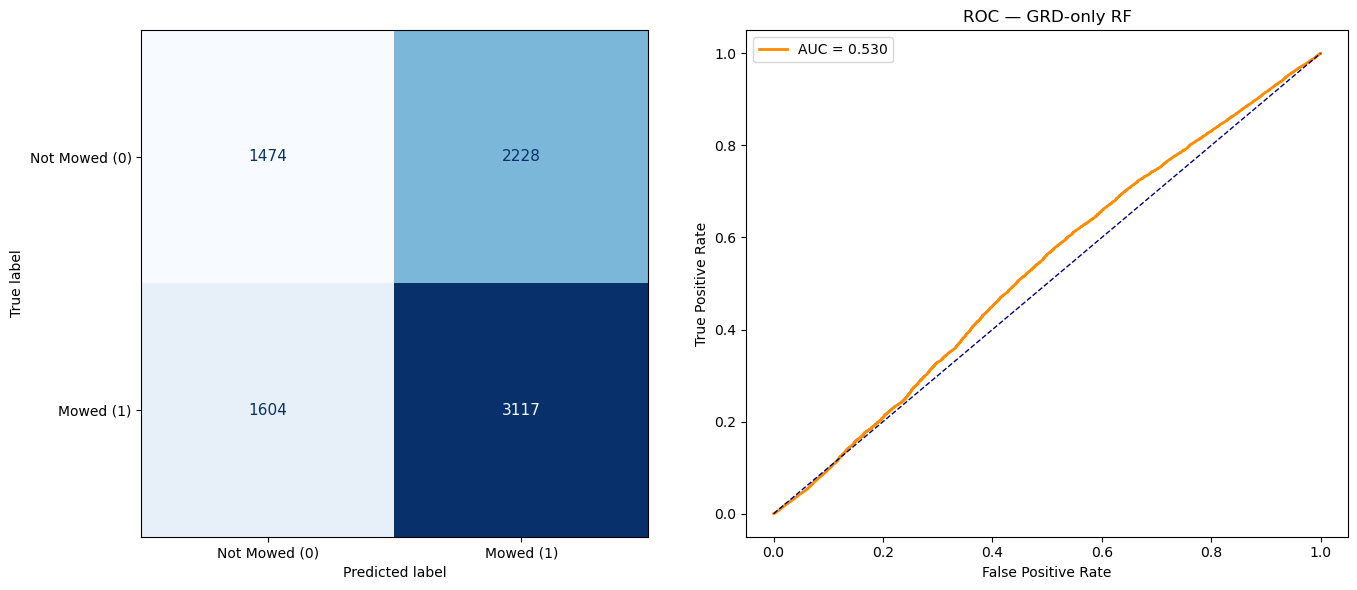

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'svm__C': 0.1, 'svm__gamma': 'scale'}

--- GRD-only SVM ---
Accuracy: 55.84%
               precision    recall  f1-score   support

Not Mowed (0)       0.49      0.19      0.28      3702
    Mowed (1)       0.57      0.84      0.68      4721

     accuracy                           0.56      8423
    macro avg       0.53      0.52      0.48      8423
 weighted avg       0.54      0.56      0.50      8423



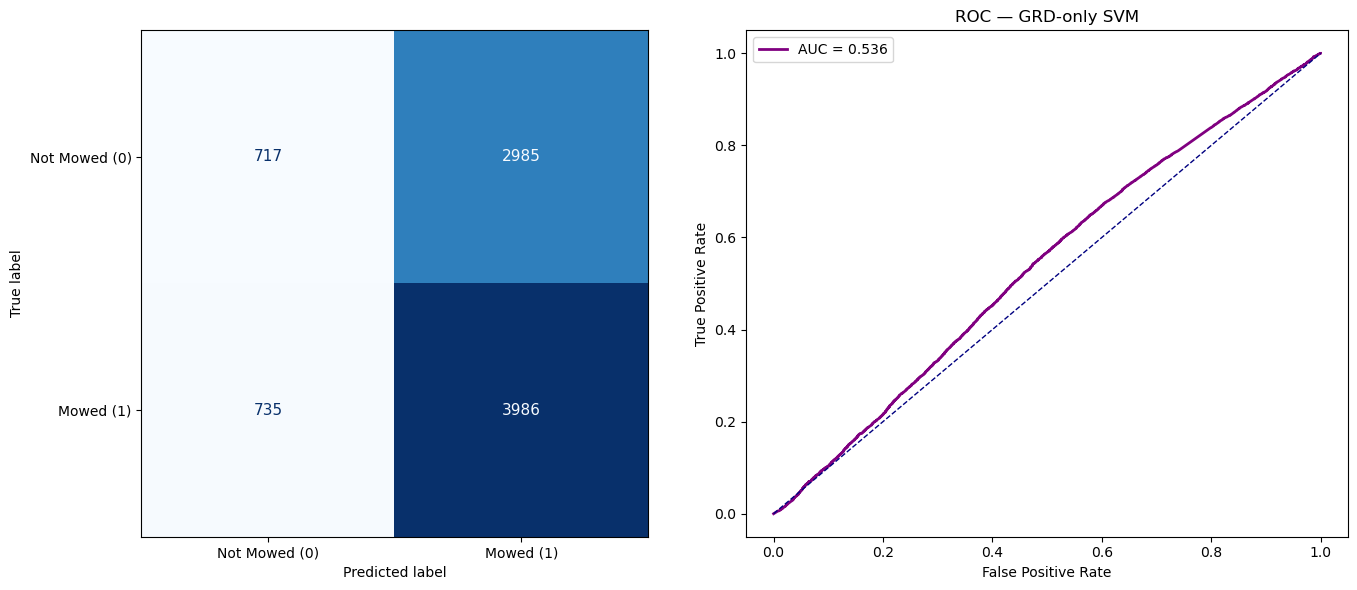

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best params: {'lgbm__learning_rate': 0.05, 'lgbm__num_leaves': 31}

--- GRD-only LGBM ---
Accuracy: 54.84%
               precision    recall  f1-score   support

Not Mowed (0)       0.48      0.37      0.42      3702
    Mowed (1)       0.58      0.69      0.63      4721

     accuracy                           0.55      8423
    macro avg       0.53      0.53      0.52      8423
 weighted avg       0.54      0.55      0.54      8423



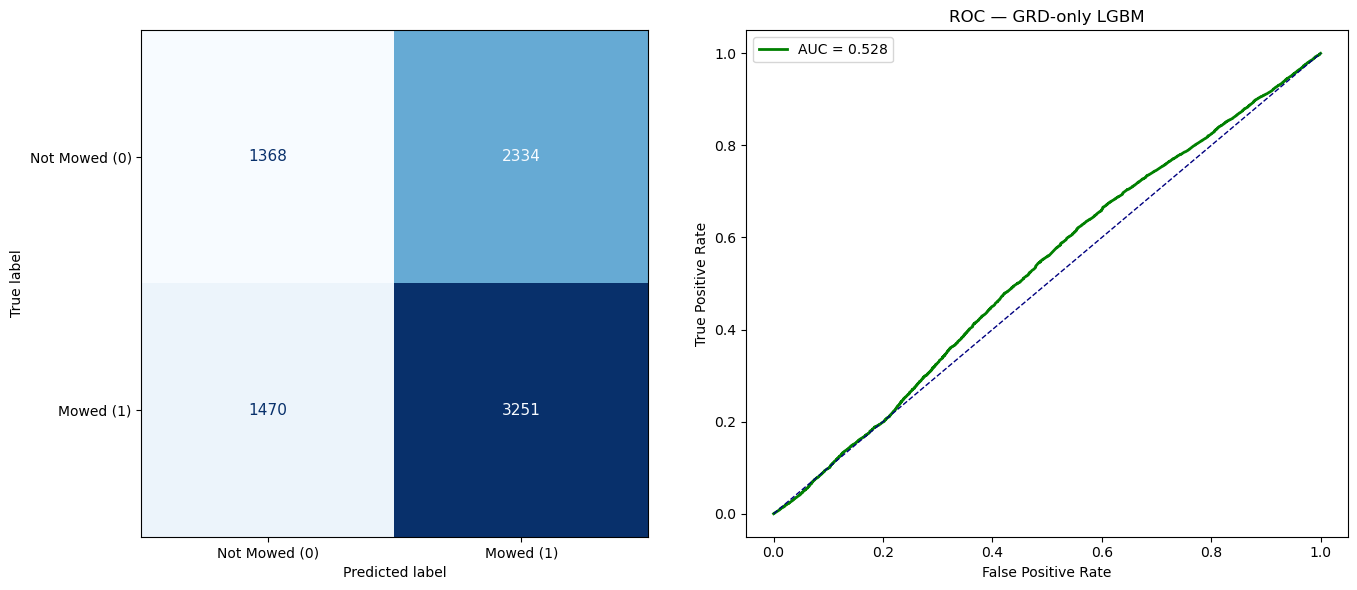

In [19]:
_feats = CONFIGS['GRD-only']['features']
print(f'=== GRD-only  ({len(_feats)} features, Group A) ===')
model_grd_only_rf = train_tuned_rf(
    X_train_A[_feats], y_train_A, groups_train_A,
    X_test_A[_feats], y_test_A,
    results_list=results_A, model_alias='GRD-only RF'
)
model_grd_only_svm = train_tuned_svm(
    X_train_A[_feats], y_train_A, groups_train_A,
    X_test_A[_feats], y_test_A,
    results_list=results_A, model_alias='GRD-only SVM'
)
model_grd_only_lgbm = train_tuned_lgbm(
    X_train_A[_feats], y_train_A, groups_train_A,
    X_test_A[_feats], y_test_A,
    results_list=results_A, model_alias='GRD-only LGBM'
)

=== S2+GRD  (11 features, Group A) ===
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'rf__max_depth': 10, 'rf__n_estimators': 100}

--- S2+GRD RF ---
Accuracy: 91.89%
               precision    recall  f1-score   support

Not Mowed (0)       0.86      0.98      0.91      3702
    Mowed (1)       0.98      0.87      0.92      4721

     accuracy                           0.92      8423
    macro avg       0.92      0.93      0.92      8423
 weighted avg       0.93      0.92      0.92      8423



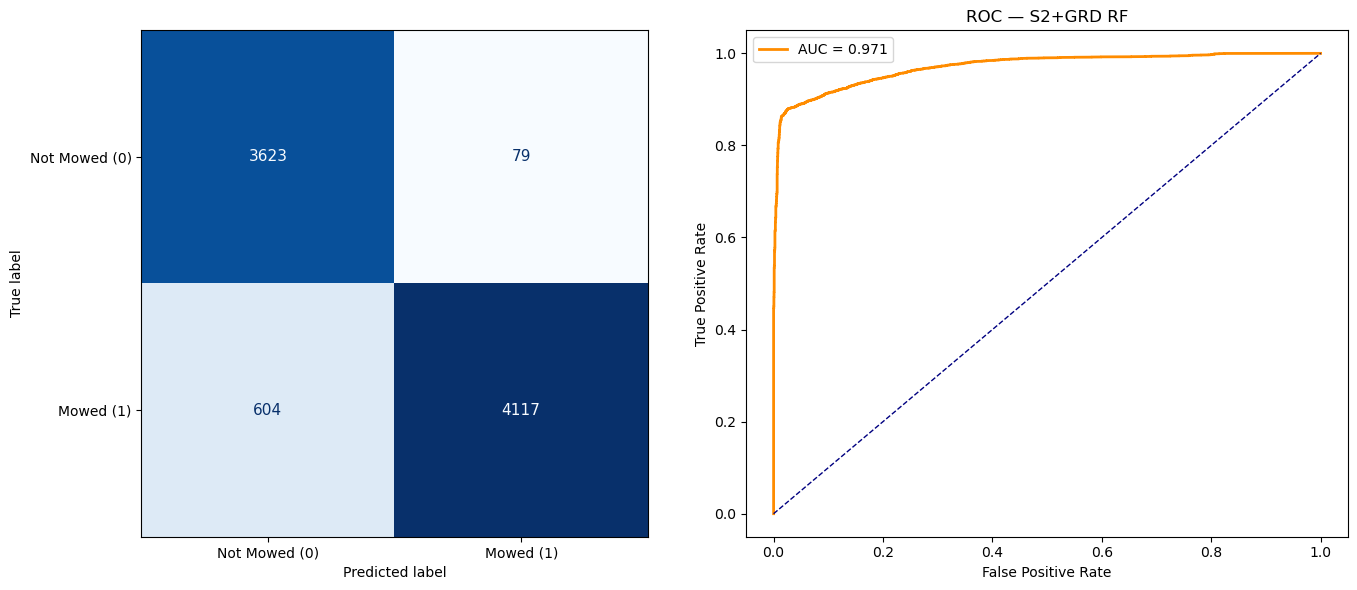

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'svm__C': 0.1, 'svm__gamma': 'scale'}

--- S2+GRD SVM ---
Accuracy: 91.02%
               precision    recall  f1-score   support

Not Mowed (0)       0.85      0.96      0.90      3702
    Mowed (1)       0.97      0.87      0.92      4721

     accuracy                           0.91      8423
    macro avg       0.91      0.92      0.91      8423
 weighted avg       0.92      0.91      0.91      8423



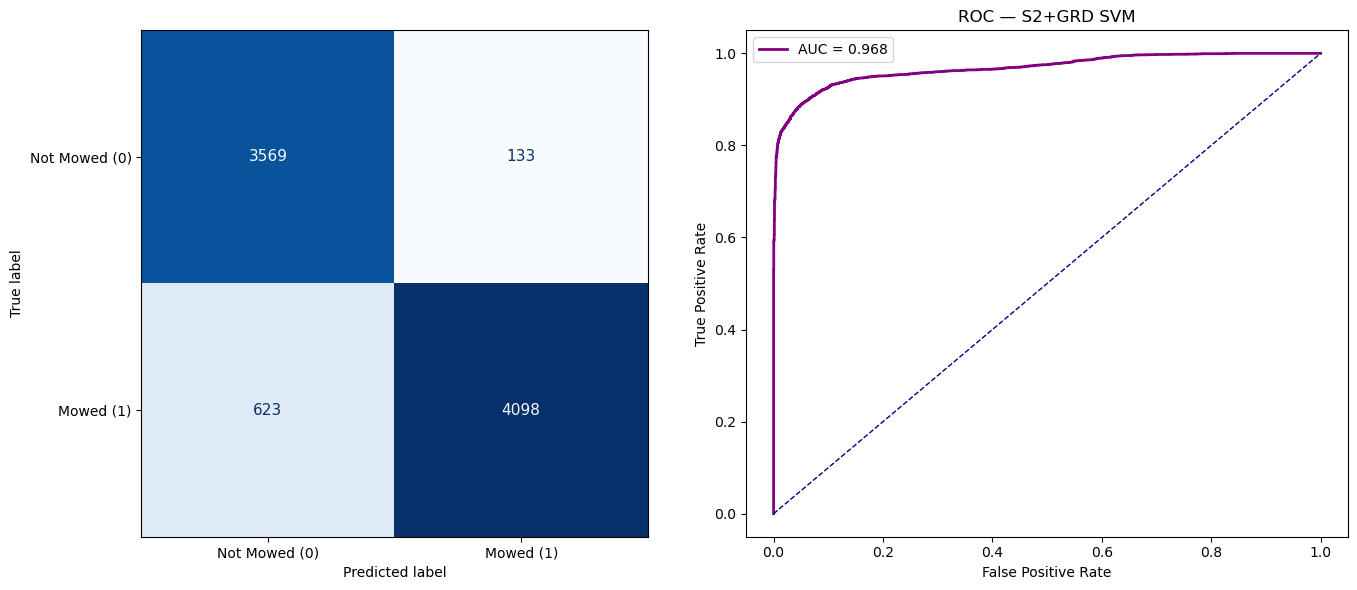

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best params: {'lgbm__learning_rate': 0.05, 'lgbm__num_leaves': 31}

--- S2+GRD LGBM ---
Accuracy: 91.00%
               precision    recall  f1-score   support

Not Mowed (0)       0.85      0.96      0.90      3702
    Mowed (1)       0.97      0.87      0.92      4721

     accuracy                           0.91      8423
    macro avg       0.91      0.92      0.91      8423
 weighted avg       0.92      0.91      0.91      8423



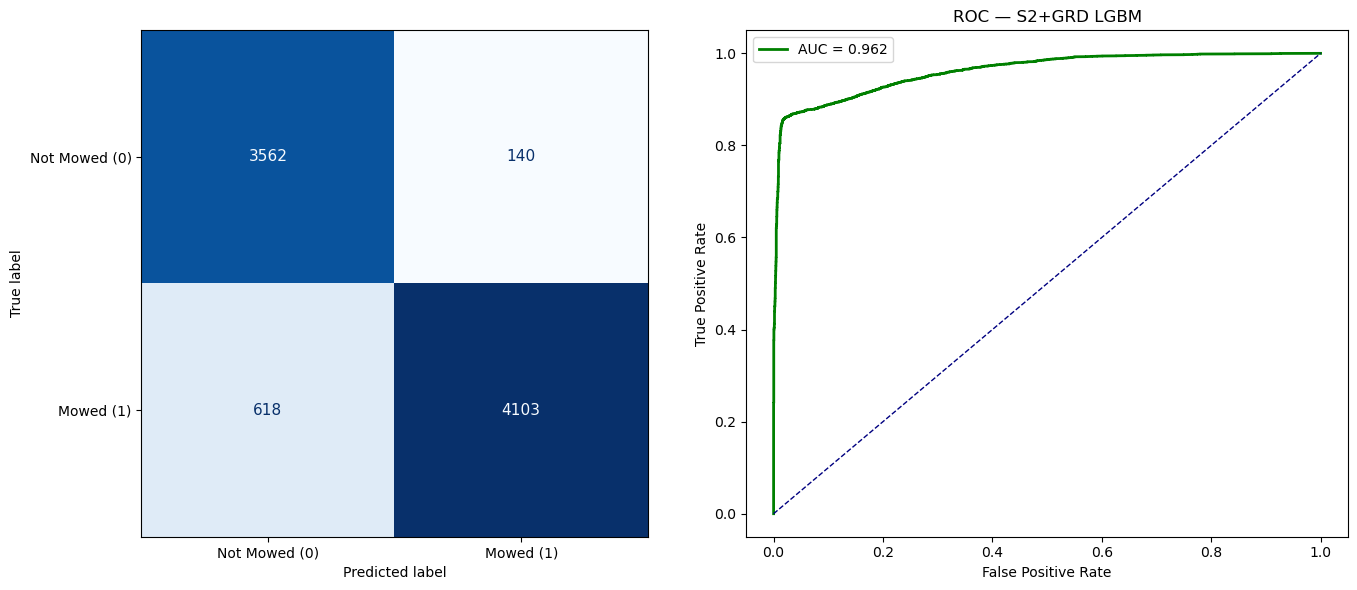

In [20]:
_feats = CONFIGS['S2+GRD']['features']
print(f'=== S2+GRD  ({len(_feats)} features, Group A) ===')
model_s2_grd_rf = train_tuned_rf(
    X_train_A[_feats], y_train_A, groups_train_A,
    X_test_A[_feats], y_test_A,
    results_list=results_A, model_alias='S2+GRD RF'
)
model_s2_grd_svm = train_tuned_svm(
    X_train_A[_feats], y_train_A, groups_train_A,
    X_test_A[_feats], y_test_A,
    results_list=results_A, model_alias='S2+GRD SVM'
)
model_s2_grd_lgbm = train_tuned_lgbm(
    X_train_A[_feats], y_train_A, groups_train_A,
    X_test_A[_feats], y_test_A,
    results_list=results_A, model_alias='S2+GRD LGBM'
)

---
## 4. Group B Training — Coh-only, CohJumps-only, S2+CohJumps, S2+Coh, Full-fusion

All five configs use the Group B split (`coh_df` — coherence-eligible subset).
Results accumulate in `results_B`.

=== Coh-only  (4 features, Group B) ===
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'rf__max_depth': 10, 'rf__n_estimators': 100}

--- Coh-only RF ---
Accuracy: 85.48%
               precision    recall  f1-score   support

Not Mowed (0)       0.91      0.85      0.88      1573
    Mowed (1)       0.77      0.87      0.82       948

     accuracy                           0.85      2521
    macro avg       0.84      0.86      0.85      2521
 weighted avg       0.86      0.85      0.86      2521



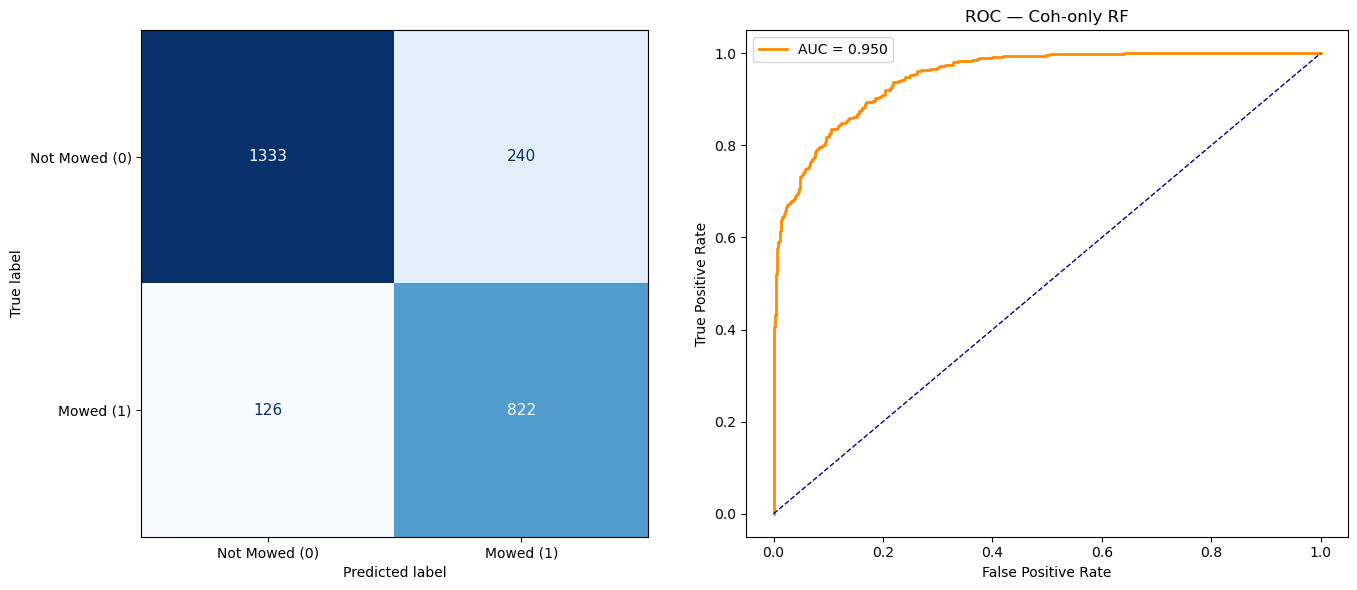

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'svm__C': 10, 'svm__gamma': 'scale'}

--- Coh-only SVM ---
Accuracy: 86.51%
               precision    recall  f1-score   support

Not Mowed (0)       0.92      0.86      0.89      1573
    Mowed (1)       0.79      0.87      0.83       948

     accuracy                           0.87      2521
    macro avg       0.85      0.87      0.86      2521
 weighted avg       0.87      0.87      0.87      2521



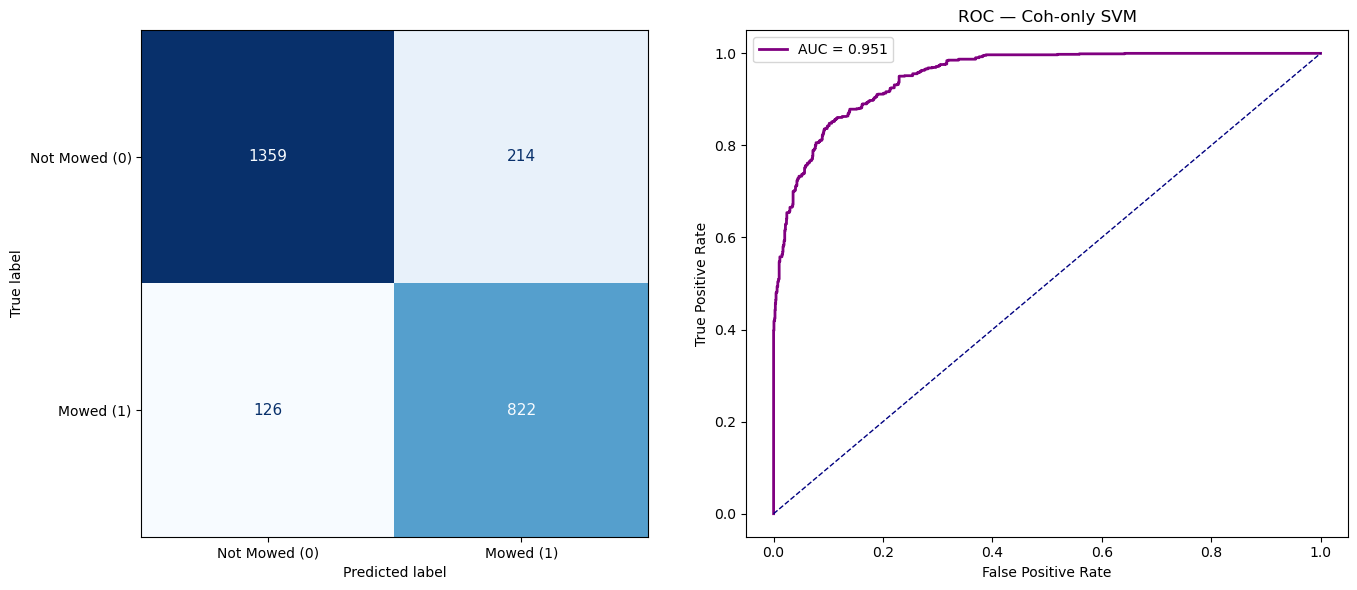

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best params: {'lgbm__learning_rate': 0.05, 'lgbm__num_leaves': 31}

--- Coh-only LGBM ---
Accuracy: 85.52%
               precision    recall  f1-score   support

Not Mowed (0)       0.91      0.85      0.88      1573
    Mowed (1)       0.78      0.86      0.82       948

     accuracy                           0.86      2521
    macro avg       0.84      0.86      0.85      2521
 weighted avg       0.86      0.86      0.86      2521



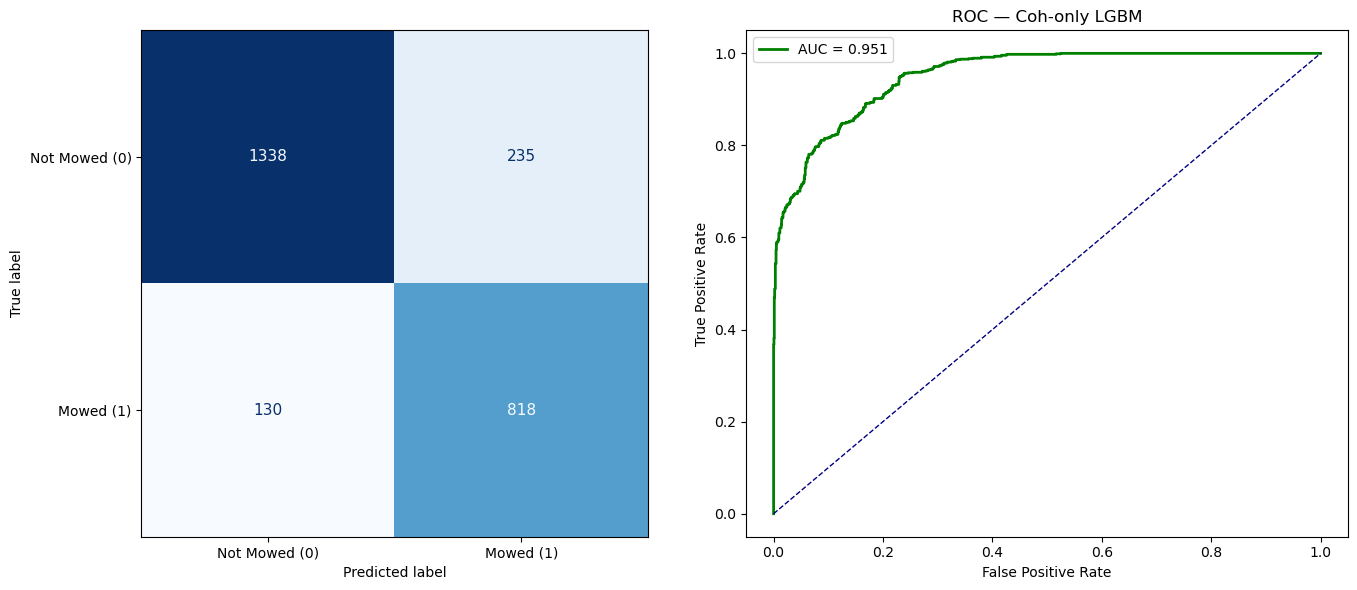

In [21]:
results_B = []

_feats = CONFIGS['Coh-only']['features']
print(f'=== Coh-only  ({len(_feats)} features, Group B) ===')
model_coh_only_rf = train_tuned_rf(
    X_train_B[_feats], y_train_B, groups_train_B,
    X_test_B[_feats], y_test_B,
    results_list=results_B, model_alias='Coh-only RF'
)
model_coh_only_svm = train_tuned_svm(
    X_train_B[_feats], y_train_B, groups_train_B,
    X_test_B[_feats], y_test_B,
    results_list=results_B, model_alias='Coh-only SVM'
)
model_coh_only_lgbm = train_tuned_lgbm(
    X_train_B[_feats], y_train_B, groups_train_B,
    X_test_B[_feats], y_test_B,
    results_list=results_B, model_alias='Coh-only LGBM'
)

=== CohJumps-only  (2 features, Group B) ===
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'rf__max_depth': 10, 'rf__n_estimators': 200}

--- CohJumps-only RF ---
Accuracy: 40.74%
               precision    recall  f1-score   support

Not Mowed (0)       0.69      0.09      0.16      1573
    Mowed (1)       0.38      0.93      0.54       948

     accuracy                           0.41      2521
    macro avg       0.54      0.51      0.35      2521
 weighted avg       0.58      0.41      0.30      2521



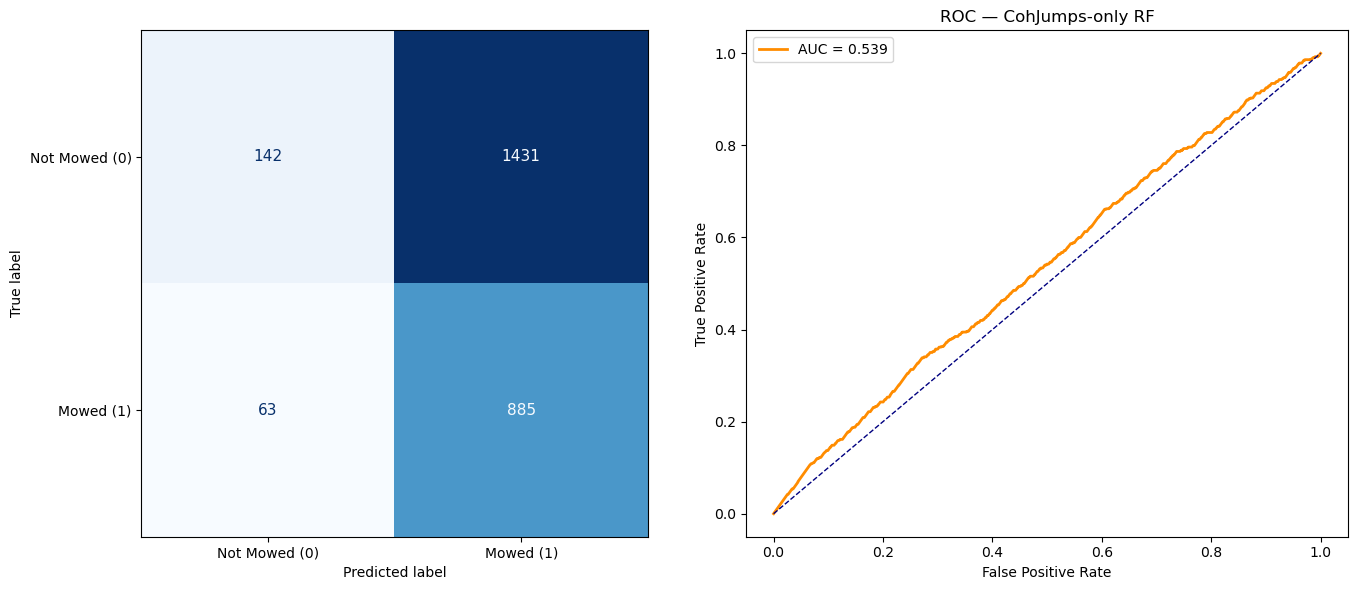

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'svm__C': 10, 'svm__gamma': 'scale'}

--- CohJumps-only SVM ---
Accuracy: 39.07%
               precision    recall  f1-score   support

Not Mowed (0)       0.66      0.05      0.09      1573
    Mowed (1)       0.38      0.96      0.54       948

     accuracy                           0.39      2521
    macro avg       0.52      0.50      0.32      2521
 weighted avg       0.55      0.39      0.26      2521



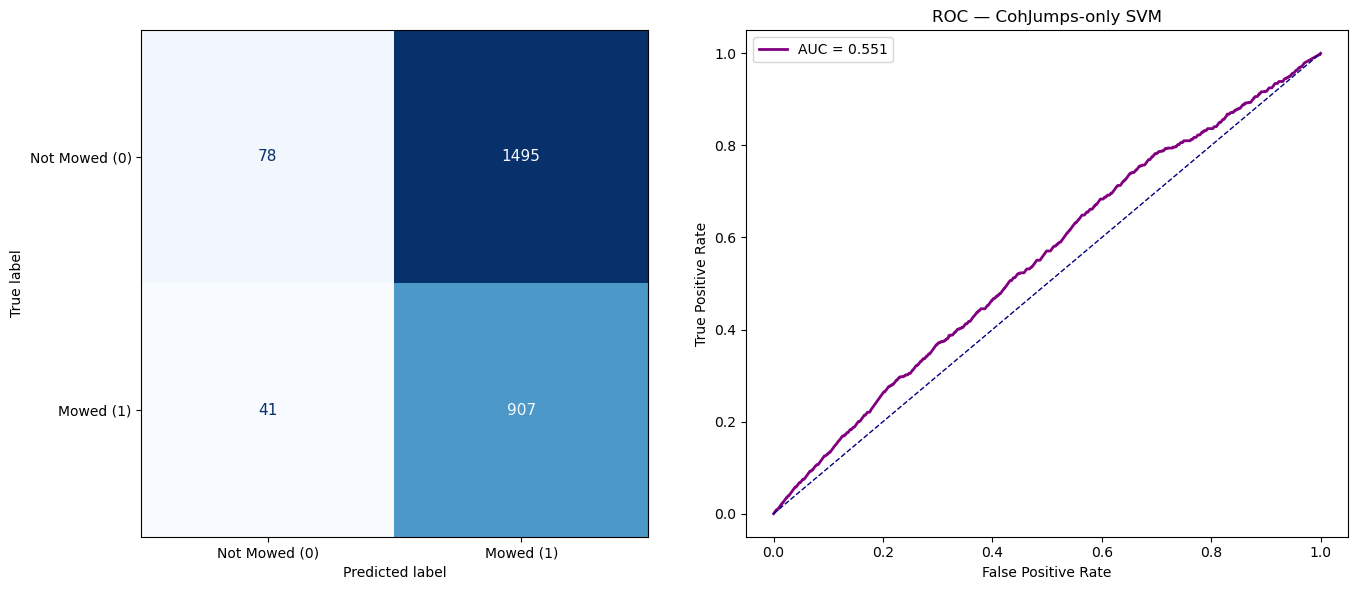

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best params: {'lgbm__learning_rate': 0.05, 'lgbm__num_leaves': 31}

--- CohJumps-only LGBM ---
Accuracy: 42.09%
               precision    recall  f1-score   support

Not Mowed (0)       0.67      0.14      0.23      1573
    Mowed (1)       0.38      0.89      0.54       948

     accuracy                           0.42      2521
    macro avg       0.53      0.51      0.38      2521
 weighted avg       0.56      0.42      0.35      2521



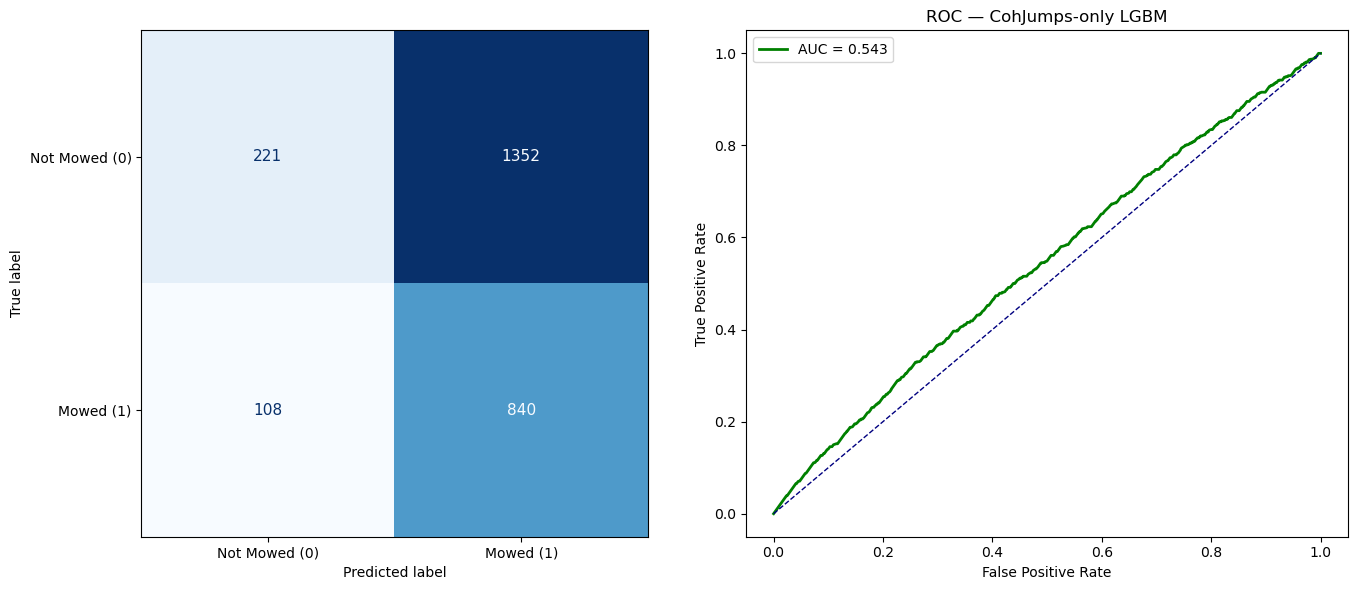

In [22]:
_feats = CONFIGS['CohJumps-only']['features']
print(f'=== CohJumps-only  ({len(_feats)} features, Group B) ===')
model_coh_jumps_rf = train_tuned_rf(
    X_train_B[_feats], y_train_B, groups_train_B,
    X_test_B[_feats], y_test_B,
    results_list=results_B, model_alias='CohJumps-only RF'
)
model_coh_jumps_svm = train_tuned_svm(
    X_train_B[_feats], y_train_B, groups_train_B,
    X_test_B[_feats], y_test_B,
    results_list=results_B, model_alias='CohJumps-only SVM'
)
model_coh_jumps_lgbm = train_tuned_lgbm(
    X_train_B[_feats], y_train_B, groups_train_B,
    X_test_B[_feats], y_test_B,
    results_list=results_B, model_alias='CohJumps-only LGBM'
)

=== S2+CohJumps  (9 features, Group B) ===
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'rf__max_depth': 10, 'rf__n_estimators': 200}

--- S2+CohJumps RF ---
Accuracy: 87.78%
               precision    recall  f1-score   support

Not Mowed (0)       0.95      0.84      0.90      1573
    Mowed (1)       0.78      0.93      0.85       948

     accuracy                           0.88      2521
    macro avg       0.87      0.89      0.87      2521
 weighted avg       0.89      0.88      0.88      2521



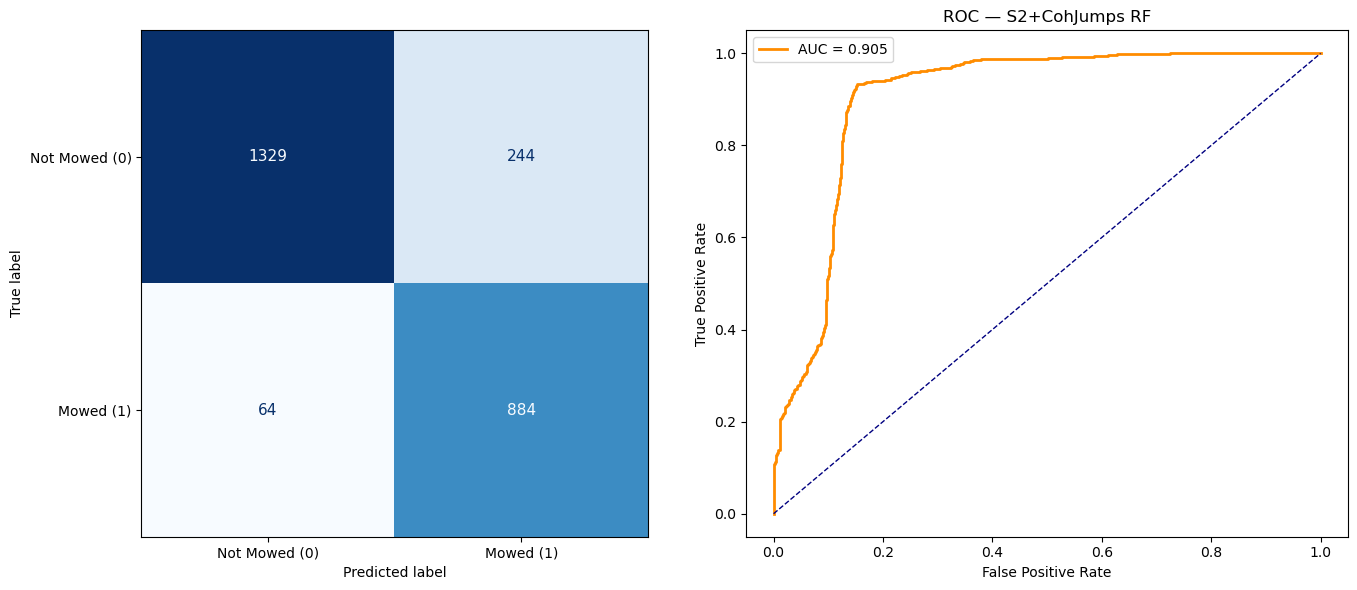

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'svm__C': 0.1, 'svm__gamma': 'scale'}

--- S2+CohJumps SVM ---
Accuracy: 89.45%
               precision    recall  f1-score   support

Not Mowed (0)       0.98      0.85      0.91      1573
    Mowed (1)       0.80      0.97      0.87       948

     accuracy                           0.89      2521
    macro avg       0.89      0.91      0.89      2521
 weighted avg       0.91      0.89      0.90      2521



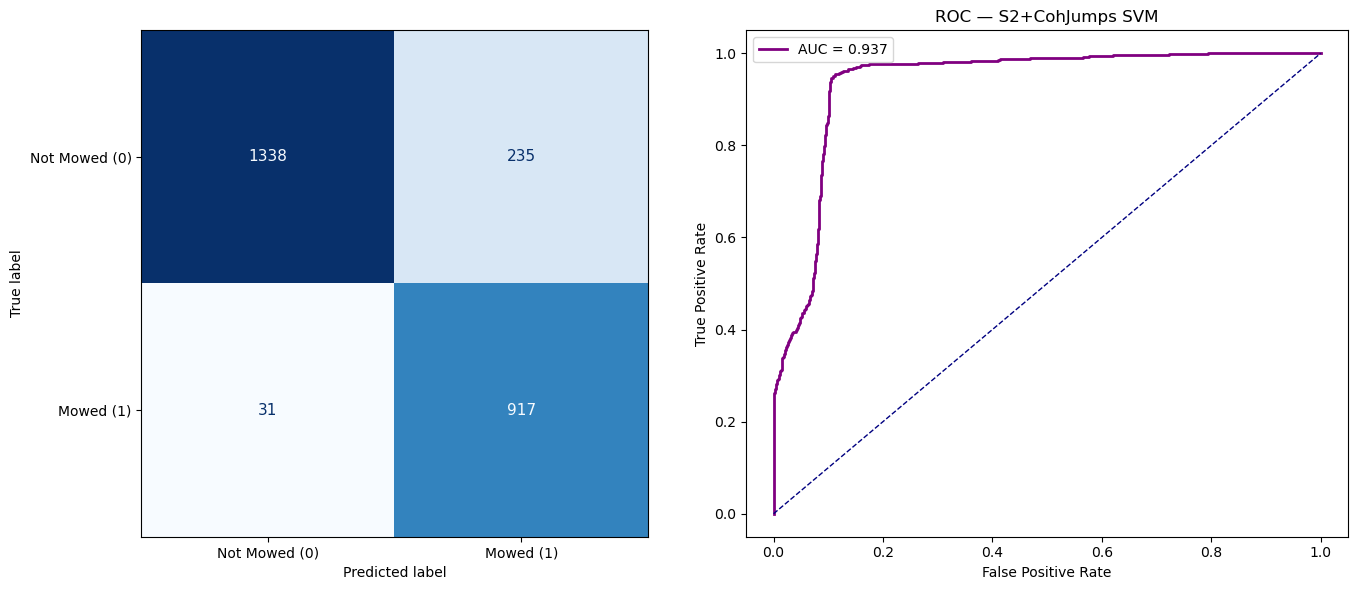

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best params: {'lgbm__learning_rate': 0.05, 'lgbm__num_leaves': 31}

--- S2+CohJumps LGBM ---
Accuracy: 85.56%
               precision    recall  f1-score   support

Not Mowed (0)       0.93      0.83      0.88      1573
    Mowed (1)       0.76      0.89      0.82       948

     accuracy                           0.86      2521
    macro avg       0.85      0.86      0.85      2521
 weighted avg       0.87      0.86      0.86      2521



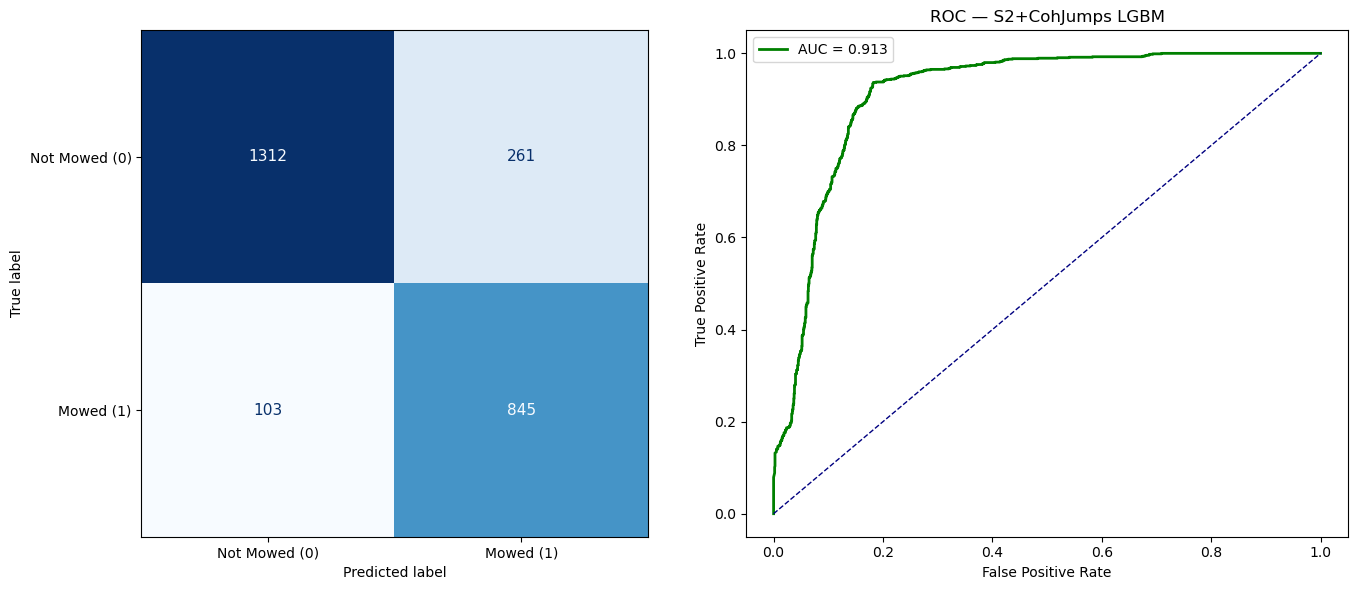

In [23]:
_feats = CONFIGS['S2+CohJumps']['features']
print(f'=== S2+CohJumps  ({len(_feats)} features, Group B) ===')
model_s2_coh_jumps_rf = train_tuned_rf(
    X_train_B[_feats], y_train_B, groups_train_B,
    X_test_B[_feats], y_test_B,
    results_list=results_B, model_alias='S2+CohJumps RF'
)
model_s2_coh_jumps_svm = train_tuned_svm(
    X_train_B[_feats], y_train_B, groups_train_B,
    X_test_B[_feats], y_test_B,
    results_list=results_B, model_alias='S2+CohJumps SVM'
)
model_s2_coh_jumps_lgbm = train_tuned_lgbm(
    X_train_B[_feats], y_train_B, groups_train_B,
    X_test_B[_feats], y_test_B,
    results_list=results_B, model_alias='S2+CohJumps LGBM'
)

=== S2+Coh  (11 features, Group B) ===
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'rf__max_depth': 20, 'rf__n_estimators': 100}

--- S2+Coh RF ---
Accuracy: 86.71%
               precision    recall  f1-score   support

Not Mowed (0)       0.94      0.84      0.89      1573
    Mowed (1)       0.78      0.91      0.84       948

     accuracy                           0.87      2521
    macro avg       0.86      0.87      0.86      2521
 weighted avg       0.88      0.87      0.87      2521



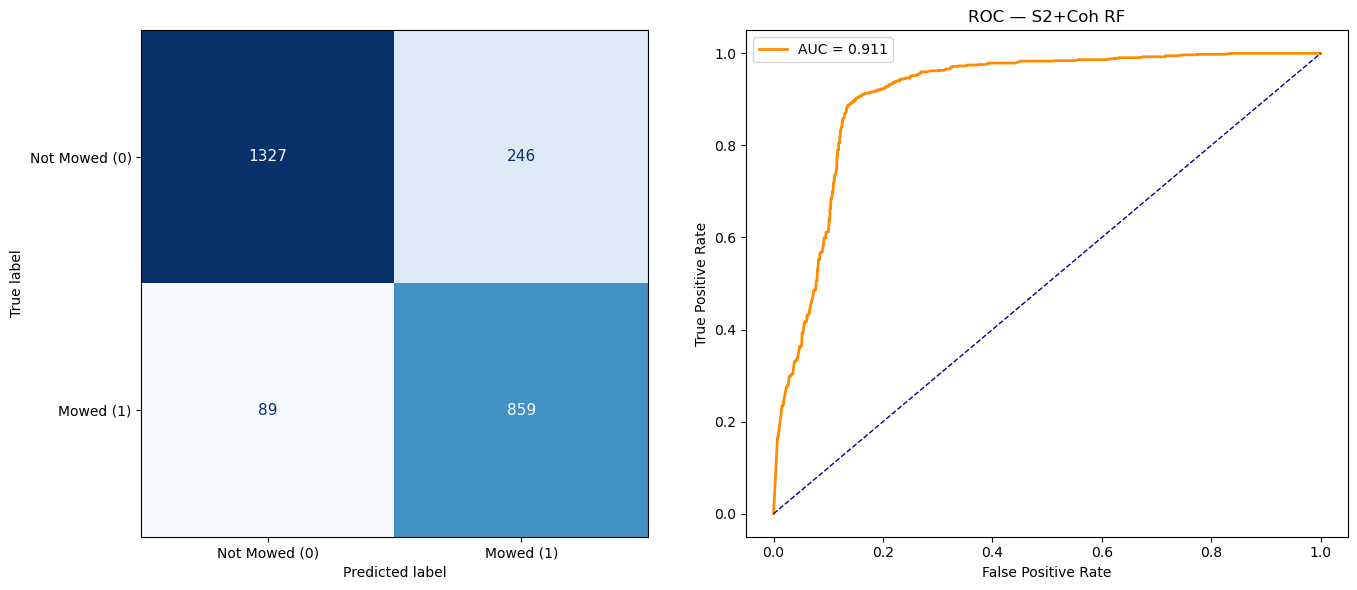

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'svm__C': 1, 'svm__gamma': 'scale'}

--- S2+Coh SVM ---
Accuracy: 92.90%
               precision    recall  f1-score   support

Not Mowed (0)       0.99      0.90      0.94      1573
    Mowed (1)       0.85      0.98      0.91       948

     accuracy                           0.93      2521
    macro avg       0.92      0.94      0.93      2521
 weighted avg       0.94      0.93      0.93      2521



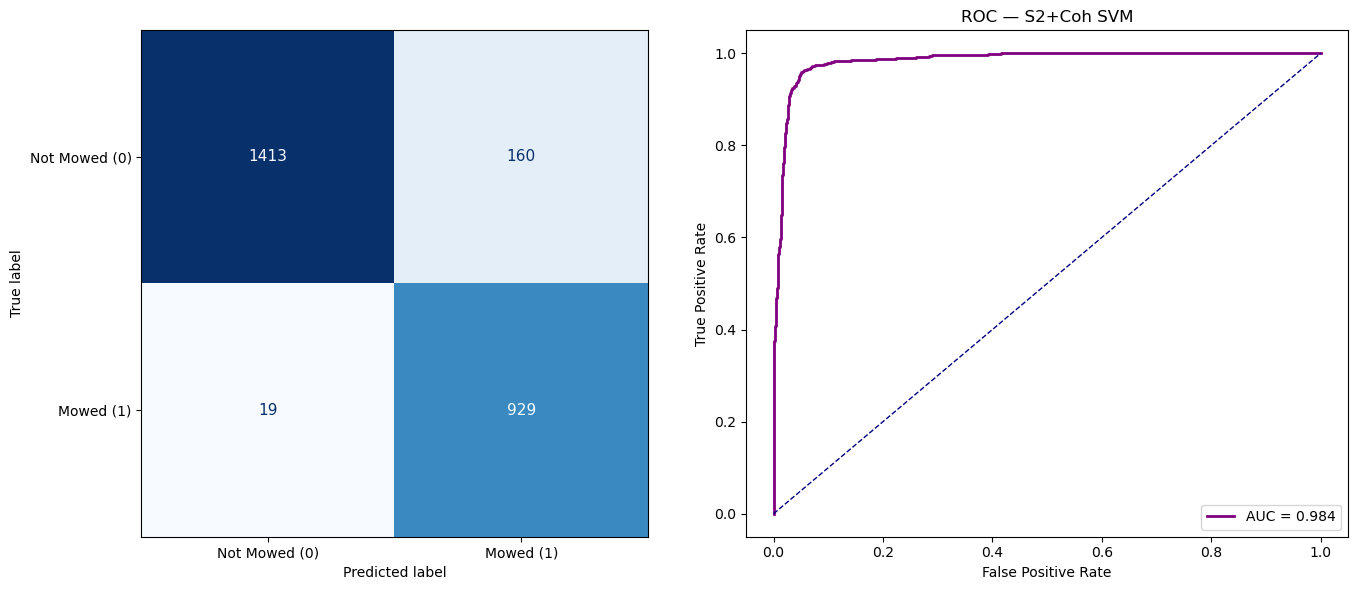

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best params: {'lgbm__learning_rate': 0.1, 'lgbm__num_leaves': 31}

--- S2+Coh LGBM ---
Accuracy: 87.47%
               precision    recall  f1-score   support

Not Mowed (0)       0.94      0.85      0.89      1573
    Mowed (1)       0.79      0.91      0.84       948

     accuracy                           0.87      2521
    macro avg       0.86      0.88      0.87      2521
 weighted avg       0.88      0.87      0.88      2521



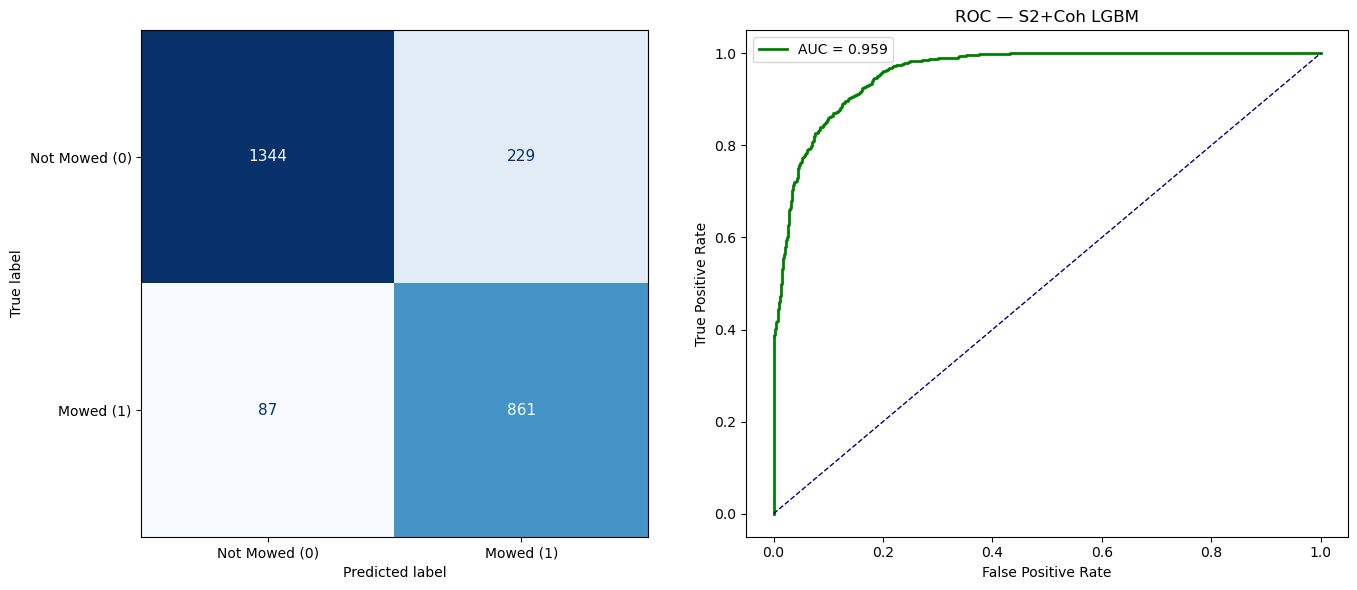

In [24]:
_feats = CONFIGS['S2+Coh']['features']
print(f'=== S2+Coh  ({len(_feats)} features, Group B) ===')
model_s2_coh_rf = train_tuned_rf(
    X_train_B[_feats], y_train_B, groups_train_B,
    X_test_B[_feats], y_test_B,
    results_list=results_B, model_alias='S2+Coh RF'
)
model_s2_coh_svm = train_tuned_svm(
    X_train_B[_feats], y_train_B, groups_train_B,
    X_test_B[_feats], y_test_B,
    results_list=results_B, model_alias='S2+Coh SVM'
)
model_s2_coh_lgbm = train_tuned_lgbm(
    X_train_B[_feats], y_train_B, groups_train_B,
    X_test_B[_feats], y_test_B,
    results_list=results_B, model_alias='S2+Coh LGBM'
)

=== Full-fusion  (15 features, Group B) ===
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'rf__max_depth': None, 'rf__n_estimators': 100}

--- Full-fusion RF ---
Accuracy: 87.62%
               precision    recall  f1-score   support

Not Mowed (0)       0.95      0.85      0.90      1573
    Mowed (1)       0.78      0.93      0.85       948

     accuracy                           0.88      2521
    macro avg       0.87      0.89      0.87      2521
 weighted avg       0.89      0.88      0.88      2521



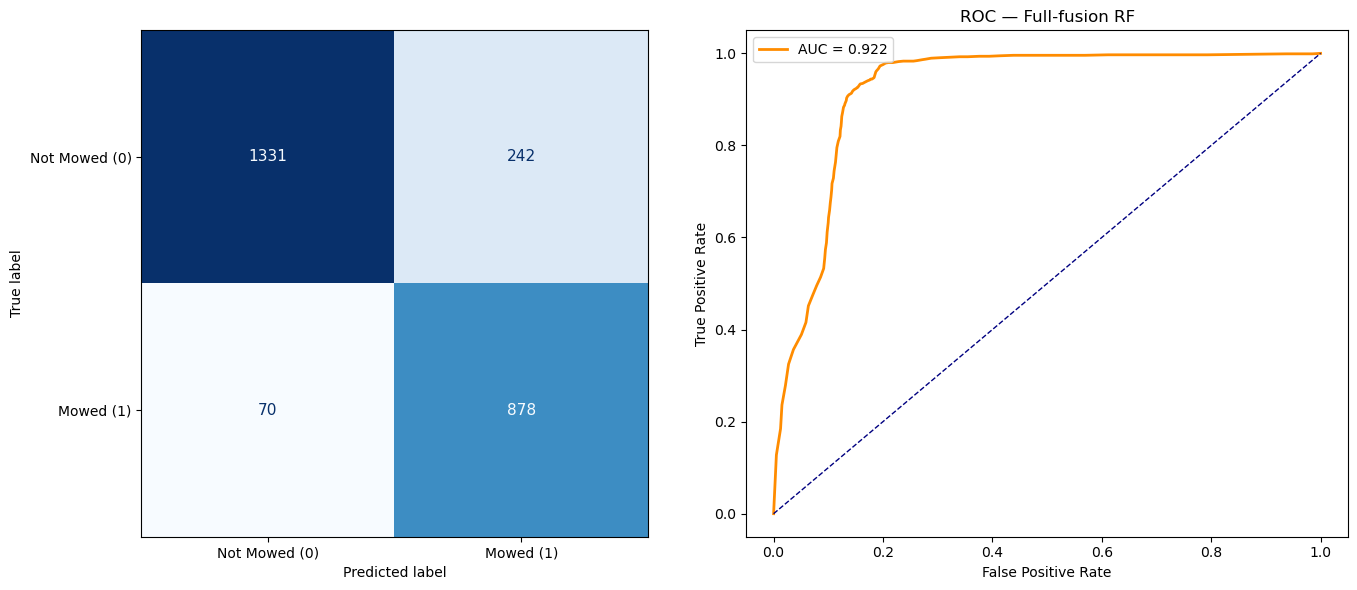

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'svm__C': 0.1, 'svm__gamma': 'scale'}

--- Full-fusion SVM ---
Accuracy: 90.84%
               precision    recall  f1-score   support

Not Mowed (0)       0.98      0.87      0.92      1573
    Mowed (1)       0.82      0.97      0.89       948

     accuracy                           0.91      2521
    macro avg       0.90      0.92      0.91      2521
 weighted avg       0.92      0.91      0.91      2521



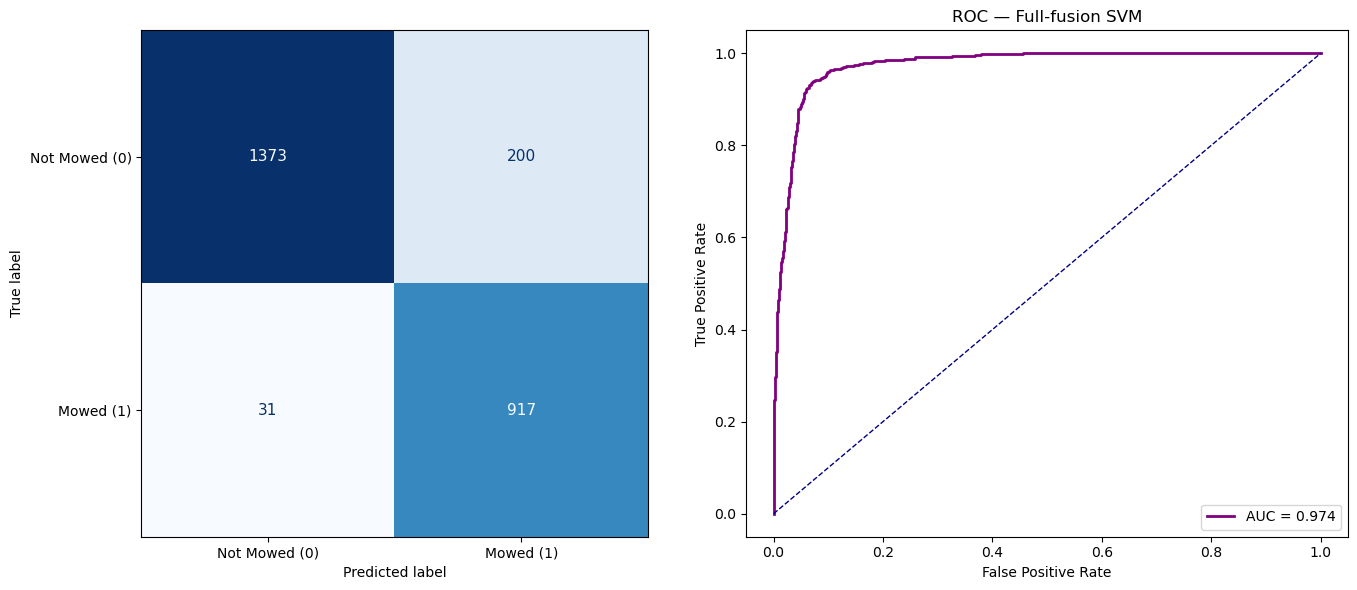

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best params: {'lgbm__learning_rate': 0.1, 'lgbm__num_leaves': 63}

--- Full-fusion LGBM ---
Accuracy: 87.50%
               precision    recall  f1-score   support

Not Mowed (0)       0.94      0.86      0.90      1573
    Mowed (1)       0.79      0.91      0.85       948

     accuracy                           0.88      2521
    macro avg       0.86      0.88      0.87      2521
 weighted avg       0.88      0.88      0.88      2521



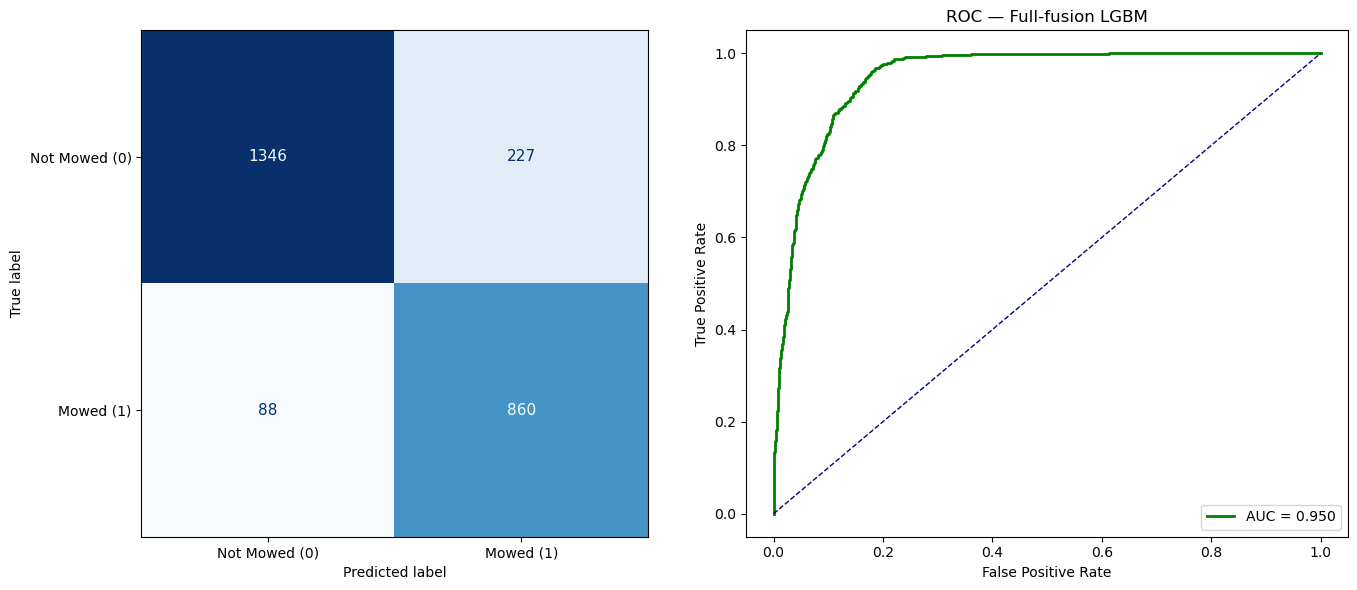

In [25]:
_feats = CONFIGS['Full-fusion']['features']
print(f'=== Full-fusion  ({len(_feats)} features, Group B) ===')
model_full_fusion_rf = train_tuned_rf(
    X_train_B[_feats], y_train_B, groups_train_B,
    X_test_B[_feats], y_test_B,
    results_list=results_B, model_alias='Full-fusion RF'
)
model_full_fusion_svm = train_tuned_svm(
    X_train_B[_feats], y_train_B, groups_train_B,
    X_test_B[_feats], y_test_B,
    results_list=results_B, model_alias='Full-fusion SVM'
)
model_full_fusion_lgbm = train_tuned_lgbm(
    X_train_B[_feats], y_train_B, groups_train_B,
    X_test_B[_feats], y_test_B,
    results_list=results_B, model_alias='Full-fusion LGBM'
)

---
## 5. Results Summary and Model Export

In [26]:
# Compile all results and compute optimal thresholds
_model_registry = {
    'S2-only RF':          (model_s2only_rf,         'S2-only'),
    'S2-only SVM':         (model_s2only_svm,         'S2-only'),
    'S2-only LGBM':        (model_s2only_lgbm,        'S2-only'),
    'GRD-only RF':         (model_grd_only_rf,        'GRD-only'),
    'GRD-only SVM':        (model_grd_only_svm,       'GRD-only'),
    'GRD-only LGBM':       (model_grd_only_lgbm,      'GRD-only'),
    'S2+GRD RF':           (model_s2_grd_rf,          'S2+GRD'),
    'S2+GRD SVM':          (model_s2_grd_svm,         'S2+GRD'),
    'S2+GRD LGBM':         (model_s2_grd_lgbm,        'S2+GRD'),
    'Coh-only RF':         (model_coh_only_rf,        'Coh-only'),
    'Coh-only SVM':        (model_coh_only_svm,       'Coh-only'),
    'Coh-only LGBM':       (model_coh_only_lgbm,      'Coh-only'),
    'CohJumps-only RF':    (model_coh_jumps_rf,       'CohJumps-only'),
    'CohJumps-only SVM':   (model_coh_jumps_svm,      'CohJumps-only'),
    'CohJumps-only LGBM':  (model_coh_jumps_lgbm,     'CohJumps-only'),
    'S2+CohJumps RF':      (model_s2_coh_jumps_rf,    'S2+CohJumps'),
    'S2+CohJumps SVM':     (model_s2_coh_jumps_svm,   'S2+CohJumps'),
    'S2+CohJumps LGBM':    (model_s2_coh_jumps_lgbm,  'S2+CohJumps'),
    'S2+Coh RF':           (model_s2_coh_rf,           'S2+Coh'),
    'S2+Coh SVM':          (model_s2_coh_svm,          'S2+Coh'),
    'S2+Coh LGBM':         (model_s2_coh_lgbm,         'S2+Coh'),
    'Full-fusion RF':      (model_full_fusion_rf,      'Full-fusion'),
    'Full-fusion SVM':     (model_full_fusion_svm,     'Full-fusion'),
    'Full-fusion LGBM':    (model_full_fusion_lgbm,    'Full-fusion'),
}

_thresh_rows = []
for alias, (model, cfg_key) in _model_registry.items():
    feats = CONFIGS[cfg_key]['features']
    grp   = CONFIGS[cfg_key]['group']
    X_t   = X_test_A if grp == 'A' else X_test_B
    y_t   = y_test_A if grp == 'A' else y_test_B
    t, _  = find_optimal_threshold(model, X_t[feats], y_t)
    _thresh_rows.append({'Model': alias, 'Threshold': round(t, 4)})

_thresh_df = pd.DataFrame(_thresh_rows)
_all_raw = pd.concat([
    pd.DataFrame(results_A).assign(Group='A'),
    pd.DataFrame(results_B).assign(Group='B'),
], ignore_index=True)
summary_df = _all_raw.merge(_thresh_df, on='Model', how='left')

_print_cols = ['Model', 'Group', 'Num_Features', 'F1_Score', 'Precision', 'Recall', 'Threshold']
print('=== Final Results: 8 Configs × 3 Algorithms (sorted by F1 desc) ===')
print(summary_df[_print_cols]
      .sort_values('F1_Score', ascending=False)
      .reset_index(drop=True)
      .to_string(index=False, float_format=lambda x: f'{x:.4f}'))

=== Final Results: 8 Configs × 3 Algorithms (sorted by F1 desc) ===
             Model Group  Num_Features  F1_Score  Precision  Recall  Threshold
        S2+Coh SVM     B            11    0.9298     0.9365  0.9290     0.8467
       S2-only SVM     A             7    0.9213     0.9282  0.9210     0.2262
         S2+GRD RF     A            11    0.9192     0.9266  0.9189     0.4100
        S2-only RF     A             7    0.9180     0.9253  0.9177     0.2752
      S2-only LGBM     A             7    0.9107     0.9171  0.9104     0.5612
        S2+GRD SVM     A            11    0.9106     0.9171  0.9102     0.2109
       S2+GRD LGBM     A            11    0.9103     0.9165  0.9100     0.6582
   Full-fusion SVM     B            15    0.9095     0.9189  0.9084     0.9182
   S2+CohJumps SVM     B             9    0.8960     0.9092  0.8945     0.8426
    S2+CohJumps RF     B             9    0.8794     0.8900  0.8778     0.5052
    Full-fusion RF     B            15    0.8778     0.8876  0.

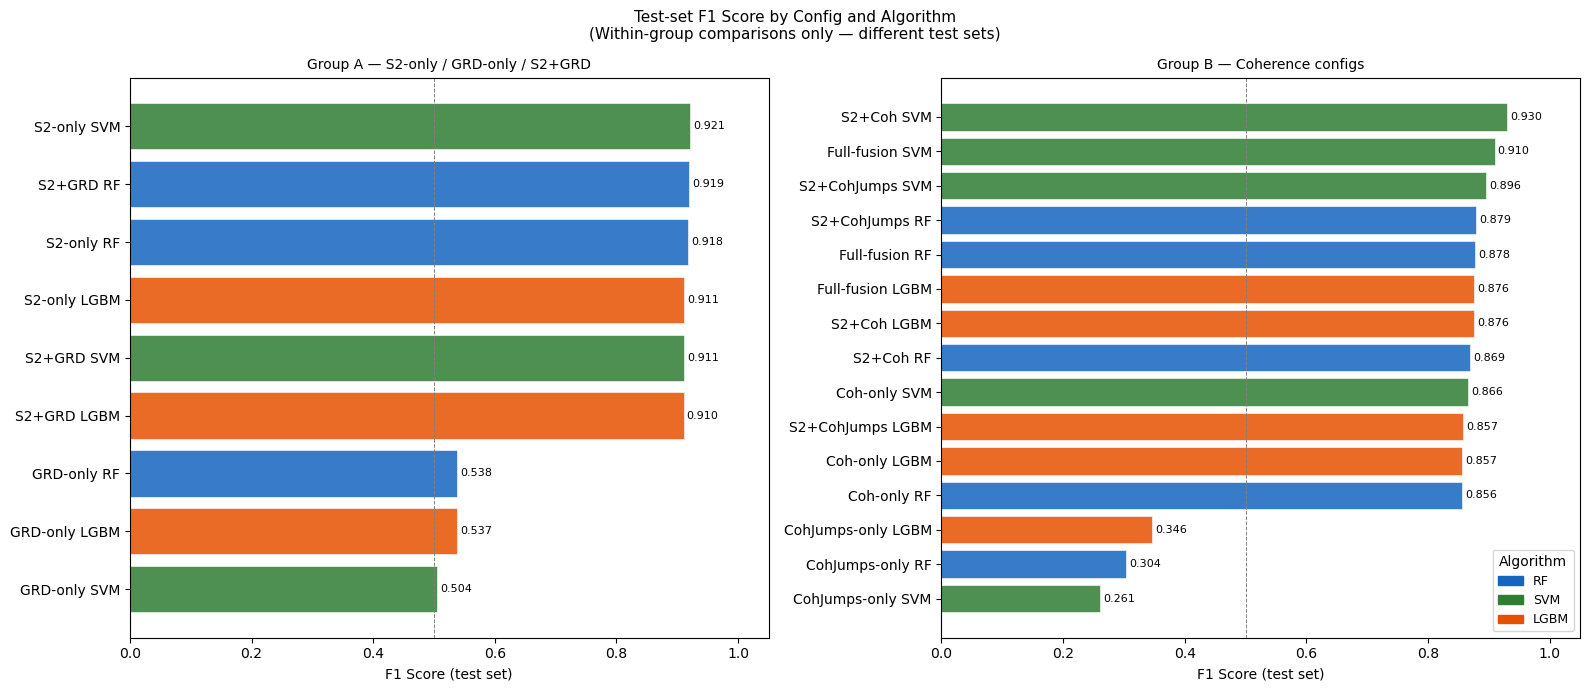

Saved → C:\Workspace\ZHAW\6_Semester\satellite-mowing-detection\data\operational_results\f1_comparison.png


In [27]:
_algo_color = {'RF': '#1565C0', 'SVM': '#2E7D32', 'LGBM': '#E65100'}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, group, title in [
    (axes[0], 'A', 'Group A — S2-only / GRD-only / S2+GRD'),
    (axes[1], 'B', 'Group B — Coherence configs'),
]:
    _g = summary_df[summary_df['Group'] == group].sort_values('F1_Score', ascending=True)
    _colors = [_algo_color[m.split()[-1]] for m in _g['Model']]
    bars = ax.barh(_g['Model'], _g['F1_Score'], color=_colors, alpha=0.85,
                   edgecolor='white', linewidth=0.5)
    ax.set_xlabel('F1 Score (test set)')
    ax.set_title(title, fontsize=10)
    ax.set_xlim(0, 1.05)
    ax.axvline(0.5, color='grey', linestyle='--', linewidth=0.7)
    for bar, val in zip(bars, _g['F1_Score']):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8)

_legend_patches = [
    mpatches.Patch(color=c, label=algo) for algo, c in _algo_color.items()
]
axes[1].legend(handles=_legend_patches, loc='lower right', fontsize=9, title='Algorithm')
plt.suptitle('Test-set F1 Score by Config and Algorithm\n'
             '(Within-group comparisons only — different test sets)', fontsize=11)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'f1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {RESULTS_DIR / "f1_comparison.png"}')

In [28]:
# Remove old model artifacts from the previous 9-config experiment
_old_artifacts = [
    's2coh_svm.joblib', 's2coh_rf.joblib', 's2coh_lgbm.joblib',
    's2coh_jumps_svm.joblib', 's2coh_jumps_rf.joblib', 's2coh_jumps_lgbm.joblib',
]
for _fn in _old_artifacts:
    _p = os.path.join(MODELS_DIR, _fn)
    if os.path.exists(_p):
        os.remove(_p)
        print(f'Removed: {_fn}')

# Save all 24 models: 8 configs × 3 algorithms
_save_spec = [
    (model_s2only_rf,         'S2-only',       's2only_rf.joblib'),
    (model_s2only_svm,        'S2-only',       's2only_svm.joblib'),
    (model_s2only_lgbm,       'S2-only',       's2only_lgbm.joblib'),
    (model_grd_only_rf,       'GRD-only',      'grd_only_rf.joblib'),
    (model_grd_only_svm,      'GRD-only',      'grd_only_svm.joblib'),
    (model_grd_only_lgbm,     'GRD-only',      'grd_only_lgbm.joblib'),
    (model_s2_grd_rf,         'S2+GRD',        's2_grd_rf.joblib'),
    (model_s2_grd_svm,        'S2+GRD',        's2_grd_svm.joblib'),
    (model_s2_grd_lgbm,       'S2+GRD',        's2_grd_lgbm.joblib'),
    (model_coh_only_rf,       'Coh-only',      'coh_only_rf.joblib'),
    (model_coh_only_svm,      'Coh-only',      'coh_only_svm.joblib'),
    (model_coh_only_lgbm,     'Coh-only',      'coh_only_lgbm.joblib'),
    (model_coh_jumps_rf,      'CohJumps-only', 'coh_jumps_only_rf.joblib'),
    (model_coh_jumps_svm,     'CohJumps-only', 'coh_jumps_only_svm.joblib'),
    (model_coh_jumps_lgbm,    'CohJumps-only', 'coh_jumps_only_lgbm.joblib'),
    (model_s2_coh_jumps_rf,   'S2+CohJumps',   's2_coh_jumps_rf.joblib'),
    (model_s2_coh_jumps_svm,  'S2+CohJumps',   's2_coh_jumps_svm.joblib'),
    (model_s2_coh_jumps_lgbm, 'S2+CohJumps',   's2_coh_jumps_lgbm.joblib'),
    (model_s2_coh_rf,         'S2+Coh',        's2_coh_rf.joblib'),
    (model_s2_coh_svm,        'S2+Coh',        's2_coh_svm.joblib'),
    (model_s2_coh_lgbm,       'S2+Coh',        's2_coh_lgbm.joblib'),
    (model_full_fusion_rf,    'Full-fusion',   'full_fusion_rf.joblib'),
    (model_full_fusion_svm,   'Full-fusion',   'full_fusion_svm.joblib'),
    (model_full_fusion_lgbm,  'Full-fusion',   'full_fusion_lgbm.joblib'),
]

_save_rows = []
for model, cfg_key, fname in _save_spec:
    feats = CONFIGS[cfg_key]['features']
    grp   = CONFIGS[cfg_key]['group']
    X_t   = X_test_A if grp == 'A' else X_test_B
    y_t   = y_test_A if grp == 'A' else y_test_B
    t, f1_opt = find_optimal_threshold(model, X_t[feats], y_t)
    joblib.dump({'model': model, 'features': feats, 'threshold': t},
                os.path.join(MODELS_DIR, fname))
    _save_rows.append({'Config': cfg_key, 'File': fname,
                       'Threshold': round(t, 4), 'F1@opt': round(f1_opt, 4)})

print('=== 24 Models Saved ===')
print(pd.DataFrame(_save_rows).to_string(index=False))
print(f'\nAll artifacts saved to: {MODELS_DIR}')

Removed: s2coh_svm.joblib
Removed: s2coh_rf.joblib
Removed: s2coh_lgbm.joblib
Removed: s2coh_jumps_svm.joblib
Removed: s2coh_jumps_rf.joblib
Removed: s2coh_jumps_lgbm.joblib
=== 24 Models Saved ===
       Config                       File  Threshold  F1@opt
      S2-only           s2only_rf.joblib     0.2752  0.9270
      S2-only          s2only_svm.joblib     0.2262  0.9423
      S2-only         s2only_lgbm.joblib     0.5612  0.9171
     GRD-only         grd_only_rf.joblib     0.3936  0.7184
     GRD-only        grd_only_svm.joblib     0.4215  0.7184
     GRD-only       grd_only_lgbm.joblib     0.3257  0.7184
       S2+GRD           s2_grd_rf.joblib     0.4100  0.9260
       S2+GRD          s2_grd_svm.joblib     0.2109  0.9253
       S2+GRD         s2_grd_lgbm.joblib     0.6582  0.9168
     Coh-only         coh_only_rf.joblib     0.5457  0.8311
     Coh-only        coh_only_svm.joblib     0.5518  0.8410
     Coh-only       coh_only_lgbm.joblib     0.5756  0.8300
CohJumps-only   coh_ju